# Cholestify — Data Science Notebook
**Analisis Nutrisi Makanan Indonesia untuk Manajemen Kolesterol**

---

| Komponen | Deskripsi |
|---|---|
| **Dataset** | `nutrition.csv` — 1.345 makanan Indonesia |
| **Kolom** | `id`, `name`, `calories`, `proteins`, `fat`, `carbohydrate`, `image` |
| **Tujuan** | EDA, Feature Engineering, A/B Testing, dan persiapan data untuk model rekomendasi makanan |

---
## Daftar Isi
1. Setup & Import Library
2. Gathering Data
3. Assessing Data
4. Cleaning Data
5. Business Questions
6. Exploratory Data Analysis (EDA)
7. Explanatory Analysis & Visualisasi
8. A/B Testing
9. Feature Engineering
10. Persiapan Data untuk Model
11. Improvement Techniques (CV, SMOTE, Augmentasi, Class Weights)
12. Data Dictionary
13. Rule-Based Food Recommendation Logic *(Bonus — Inference System)*


---
## 1. Setup & Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import missingno as msno
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Tambahan untuk improvement (Section 10)
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate, train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, accuracy_score, balanced_accuracy_score)
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Style visual
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
CHOLESTIFY_COLORS = ['#2563EB', '#16A34A', '#EA580C', '#9333EA', '#0891B2']

print('Library berhasil di-import!')

Library berhasil di-import!


---
## 2. Gathering Data
> **Tujuan:** Memuat dataset dari Kaggle dan memahami sumber data.


In [2]:
df = pd.read_csv("../data/df_nutrition.csv")
df.head(10)

,id,calories,proteins,fat,carbohydrate,name,image
0,1,280.0,9.2,28.4,0.0,Abon,https://img-cdn.medkomtek.com/PbrY9X3ignQ8sVuj...
1,2,513.0,23.7,37.0,21.3,Abon haruwan,https://img-global.cpcdn.com/recipes/cbf330fbd...
2,3,0.0,0.0,0.2,0.0,Agar-agar,https://res.cloudinary.com/dk0z4ums3/image/upl...
3,4,45.0,1.1,0.4,10.8,Akar tonjong segar,https://images.tokopedia.net/img/cache/200-squ...
4,5,37.0,4.4,0.5,3.8,Aletoge segar,https://nilaigizi.com/assets/images/produk/pro...
5,6,85.0,0.9,6.5,7.7,Alpukat segar,https://katakabar.com/assets/images/upload/new...
6,7,96.0,3.7,0.6,19.1,Ampas kacang hijau,https://images.tokopedia.net/img/cache/215-squ...
7,8,414.0,26.6,18.3,41.3,Ampas Tahu,https://palpres.disway.id/upload/9e9c1ba592cac...
8,9,75.0,4.1,2.1,10.7,Ampas tahu kukus,https://cdns.diadona.id/diadona.id/resized/640...
9,10,67.0,5.0,2.1,8.1,Ampas tahu mentah,https://cdn-image.hipwee.com/wp-content/upload...


---
## 3. Assessing Data
> **Tujuan:** Mengevaluasi kualitas data — missing values, tipe data, duplikat, dan outlier.

In [3]:
print('TIPE DATA & INFO UMUM')
print('=' * 60)
df.info()

TIPE DATA & INFO UMUM
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1346 entries, 0 to 1345
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            1346 non-null   int64  
 1   calories      1346 non-null   float64
 2   proteins      1346 non-null   float64
 3   fat           1346 non-null   float64
 4   carbohydrate  1346 non-null   float64
 5   name          1346 non-null   object 
 6   image         1346 non-null   object 
dtypes: float64(4), int64(1), object(2)
memory usage: 73.7+ KB


In [4]:
print('STATISTIK DESKRIPTIF')
print('=' * 60)
df.describe().round(2)

STATISTIK DESKRIPTIF


,id,calories,proteins,fat,carbohydrate
count,1346.00,1346.00,1346.00,1346.00,1346.00
mean,673.50,203.22,10.00,7.58,25.39
std,388.70,163.08,11.85,13.73,32.19
min,1.00,0.00,0.00,0.00,0.00
25%,337.25,75.00,1.80,0.50,4.53
50%,673.50,146.00,5.00,2.00,13.30
75%,1009.75,333.75,15.00,8.28,37.58
max,1346.00,940.00,83.00,100.00,647.00


MISSING VALUES
              Jumlah Missing  Persentase (%)
id                         0             0.0
calories                   0             0.0
proteins                   0             0.0
fat                        0             0.0
carbohydrate               0             0.0
name                       0             0.0
image                      0             0.0

 Total missing values: 0


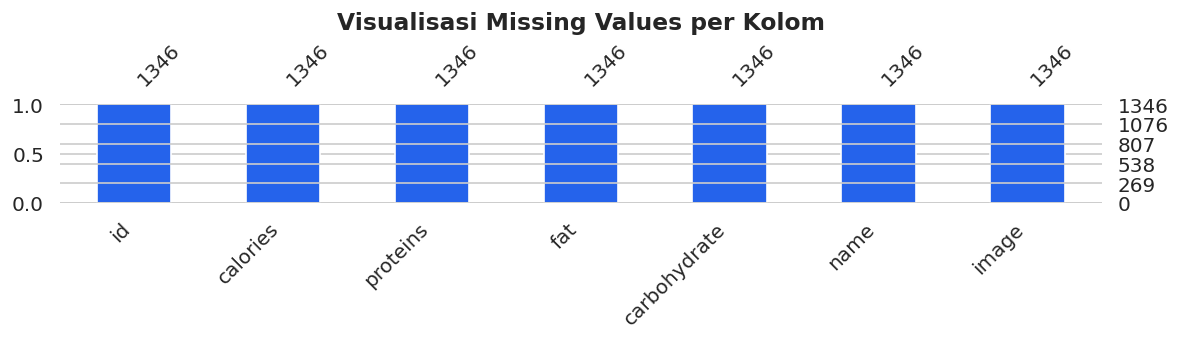

In [5]:
# --- Missing Values ---
print('MISSING VALUES')
print('=' * 60)
missing = pd.DataFrame({
    'Jumlah Missing': df.isnull().sum(),
    'Persentase (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
print(missing)

print(f'\n Total missing values: {df.isnull().sum().sum()}')

# Visualisasi missing values
fig, ax = plt.subplots(figsize=(10, 3))
msno.bar(df, ax=ax, color='#2563EB', fontsize=12)
ax.set_title('Visualisasi Missing Values per Kolom', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
# --- Duplikat ---
print('CEK DUPLIKAT')
print('=' * 60)
print(f'Duplikat baris penuh : {df.duplicated().sum()}')
print(f'Duplikat nama makanan: {df["name"].duplicated().sum()}')

if df.duplicated().sum() > 0:
    print('\nData duplikat:')
    print(df[df.duplicated()])
else:
    print('\n Tidak ada data duplikat!')

CEK DUPLIKAT
Duplikat baris penuh : 0
Duplikat nama makanan: 0

 Tidak ada data duplikat!


---
## 4. Cleaning Data
> **Tujuan:** Membersihkan data dari anomali dan mempersiapkan dataset yang bersih.

In [7]:
df_clean = df.copy()

# [1] Hapus kolom 'image' — tidak relevan untuk analisis numerik
df_clean = df_clean.drop(columns=['image'])
print('Kolom image dihapus (URL gambar, tidak relevan untuk analisis).')

# [2] Standarisasi nama makanan: strip whitespace, title case
df_clean['name'] = df_clean['name'].str.strip().str.title()
print('Nama makanan distandarisasi (strip + title case).')

# [3] Tangani item 0 kalori (Agar-agar) — bukan anomali, data valid
zero_cal = df_clean[df_clean['calories'] == 0]
print(f'\n Item dengan 0 kalori ({len(zero_cal)} item) — DIPERTAHANKAN (data valid):')
print(zero_cal[['name', 'calories', 'proteins', 'fat', 'carbohydrate']])

# [4] Outlier karbohidrat > 500 g — Pilus (647g) kemungkinan error data per 100g
#     Kita cap di 400g sebagai batas realistis
cap_carb = 400
extreme_carb = df_clean[df_clean['carbohydrate'] > cap_carb]
print(f'\n Item karbohidrat > {cap_carb}g — di-cap:')
print(extreme_carb[['name', 'carbohydrate']])
df_clean.loc[df_clean['carbohydrate'] > cap_carb, 'carbohydrate'] = cap_carb
print(f' Karbohidrat di-cap maksimal {cap_carb}g.')

print(f'\n Shape setelah cleaning: {df_clean.shape}')
df_clean.head()

Kolom image dihapus (URL gambar, tidak relevan untuk analisis).
Nama makanan distandarisasi (strip + title case).

 Item dengan 0 kalori (1 item) — DIPERTAHANKAN (data valid):
        name  calories  proteins  fat  carbohydrate
2  Agar-Agar       0.0       0.0  0.2           0.0

 Item karbohidrat > 400g — di-cap:
      name  carbohydrate
990  Pilus         647.0
 Karbohidrat di-cap maksimal 400g.

 Shape setelah cleaning: (1346, 6)


,id,calories,proteins,fat,carbohydrate,name
0,1,280.0,9.2,28.4,0.0,Abon
1,2,513.0,23.7,37.0,21.3,Abon Haruwan
2,3,0.0,0.0,0.2,0.0,Agar-Agar
3,4,45.0,1.1,0.4,10.8,Akar Tonjong Segar
4,5,37.0,4.4,0.5,3.8,Aletoge Segar


---
## 5. Business Questions
> Pertanyaan bisnis yang akan dijawab melalui analisis data.

### 📋 Daftar Business Questions Cholestify

| # | Business Question | Tipe Analisis |
|---|---|---|
| BQ1 | Apa distribusi kalori makanan Indonesia, dan berapa porsi yang masuk kategori "aman" untuk penderita kolesterol? | Deskriptif |
| BQ2 | Makanan apa saja yang memiliki lemak tinggi (>20g) tapi protein rendah (<5g)? | Diagnostik |
| BQ3 | Apakah ada korelasi antara kandungan lemak dan kalori pada makanan Indonesia? | Diagnostik |
| BQ4 | Bagaimana distribusi kategori makanan berdasarkan profil nutrisi (tinggi protein, rendah lemak, dll)? | Deskriptif |
| BQ5 | Makanan apa yang paling direkomendasikan untuk penderita kolesterol tinggi (rendah lemak, cukup protein)? | Preskriptif |

---
### 📏 Definisi Threshold Nutrisi (per 100g)

| Kategori | Kalori | Lemak | Protein | Karbohidrat |
|---|---|---|---|---|
| **Rendah** | < 100 kkal | < 3 g | < 5 g | < 10 g |
| **Sedang** | 100–300 kkal | 3–15 g | 5–15 g | 10–40 g |
| **Tinggi** | > 300 kkal | > 15 g | > 15 g | > 40 g |

---
## 6. Exploratory Data Analysis (EDA)

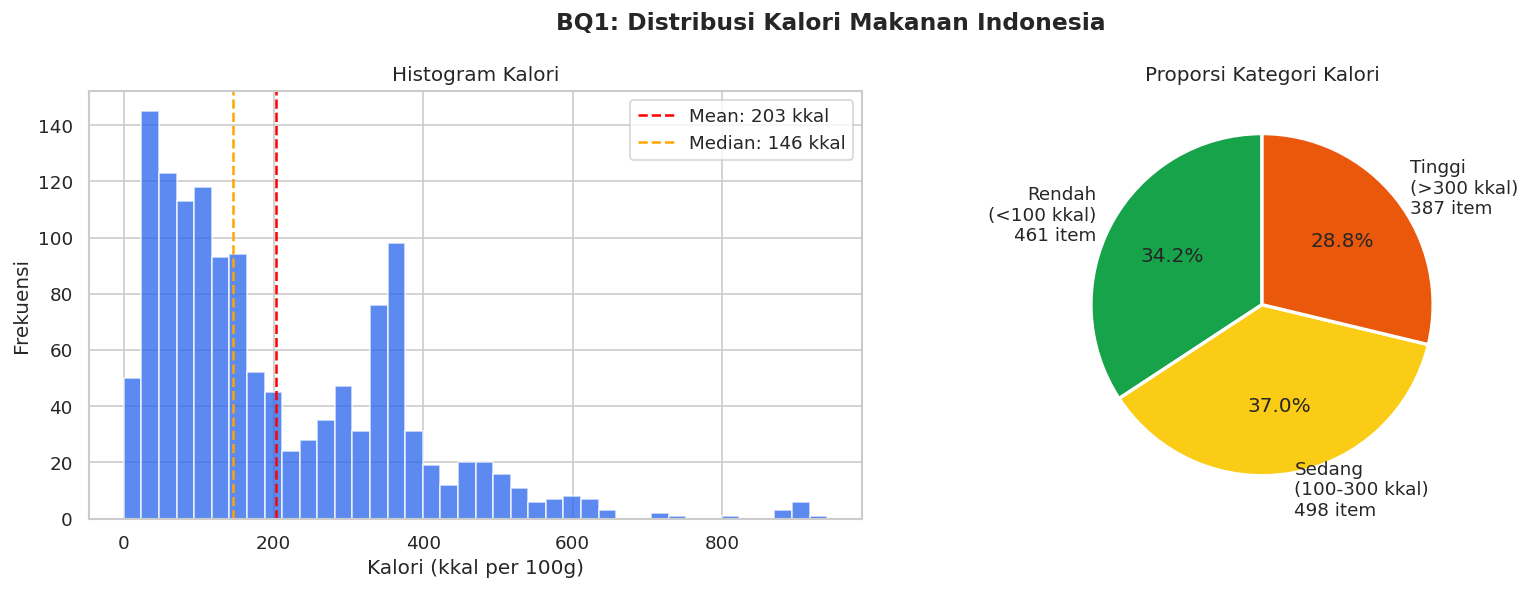

In [8]:
# BQ1 — Distribusi Kalori
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('BQ1: Distribusi Kalori Makanan Indonesia', fontsize=14, fontweight='bold')

# Histogram
axes[0].hist(df_clean['calories'], bins=40, color='#2563EB', alpha=0.75, edgecolor='white')
axes[0].axvline(df_clean['calories'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {df_clean["calories"].mean():.0f} kkal')
axes[0].axvline(df_clean['calories'].median(), color='orange', linestyle='--', linewidth=1.5, label=f'Median: {df_clean["calories"].median():.0f} kkal')
axes[0].set_xlabel('Kalori (kkal per 100g)')
axes[0].set_ylabel('Frekuensi')
axes[0].set_title('Histogram Kalori')
axes[0].legend()

# Pie chart kategori kalori
kal_rendah = (df_clean['calories'] < 100).sum()
kal_sedang = ((df_clean['calories'] >= 100) & (df_clean['calories'] <= 300)).sum()
kal_tinggi = (df_clean['calories'] > 300).sum()

sizes = [kal_rendah, kal_sedang, kal_tinggi]
labels = [f'Rendah\n(<100 kkal)\n{kal_rendah} item',
          f'Sedang\n(100-300 kkal)\n{kal_sedang} item',
          f'Tinggi\n(>300 kkal)\n{kal_tinggi} item']
colors = ['#16A34A', '#FACC15', '#EA580C']
axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,
           wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporsi Kategori Kalori')

plt.tight_layout()
plt.show()

### 🔍 Insight dari Histogram Kalori

Histogram menunjukkan distribusi kalori yang **right-skewed (menceng kanan)**, yang berarti:

- **Median (146 kkal)** jauh lebih rendah dari **Mean (203 kkal)**
- Sebagian besar makanan terkonsentrasi di kisaran **0–200 kkal per 100g**
- Terdapat **ekor panjang ke kanan** hingga >800 kkal — ini adalah makanan berlemak/berkalori ekstrem seperti minyak, mentega, atau makanan gorengan berat
- Ada **dua puncak (bimodal)**: satu di sekitar 0–50 kkal (sayur/buah rendah kalori) dan satu lagi di sekitar 300–400 kkal (makanan olahan/gorengan)

---

### 📊 Proporsi Kategori Kalori

| Kategori | Rentang | Jumlah Item | Persentase | Status untuk Kolesterol |
|---|---|---|---|---|
| 🟢 Rendah | < 100 kkal | 461 item | 34,2% | ✅ Aman |
| 🟡 Sedang | 100 – 300 kkal | 498 item | 37,0% | ⚠️ Perhatikan lemaknya |
| 🔴 Tinggi | > 300 kkal | 387 item | 28,8% | ❌ Perlu dibatasi |

---

### 💡 Jawaban Business Question

**71,2%** makanan Indonesia (kategori rendah + sedang) masuk rentang kalori yang relatif aman bagi penderita kolesterol. Namun ada dua catatan penting:

**1. Mean > Median → distribusi tidak normal**
Nilai mean 203 kkal ditarik ke atas oleh outlier makanan berkalori sangat tinggi. Ini berarti jika penderita kolesterol memilih makanan secara acak dari dataset, kemungkinan besar mereka mendapat makanan di bawah 200 kkal — namun tetap harus selektif.

**2. Kalori rendah ≠ otomatis aman untuk kolesterol**
Contoh: santan kelapa memiliki kalori sedang (~230 kkal/100g), namun kandungan lemak jenuhnya sangat tinggi. Sebaliknya, ayam rebus tanpa kulit (~165 kkal) aman karena lemaknya rendah. Oleh karena itu, **analisis kalori saja tidak cukup** — perlu dikombinasikan dengan kandungan lemak (BQ2 & BQ3).

**3. Rekomendasi praktis berdasarkan distribusi ini:**
- Prioritaskan makanan di kelompok **Rendah (<100 kkal)** — 34,2% pilihan tersedia
- Makanan **Sedang (100–300 kkal)** masih bisa dikonsumsi asal lemaknya <10g/100g
- Hindari makanan **Tinggi (>300 kkal)** kecuali sumber kalorinya berasal dari protein, bukan lemak

---

> 📌 **Kesimpulan BQ1:** Distribusi kalori makanan Indonesia cenderung rendah-sedang (median 146 kkal), dengan **71,2% makanan masuk kategori aman secara kalori**. Namun kalori bukan satu-satunya indikator — analisis lemak pada BQ2 dan BQ3 diperlukan untuk penilaian risiko kolesterol yang lebih akurat.

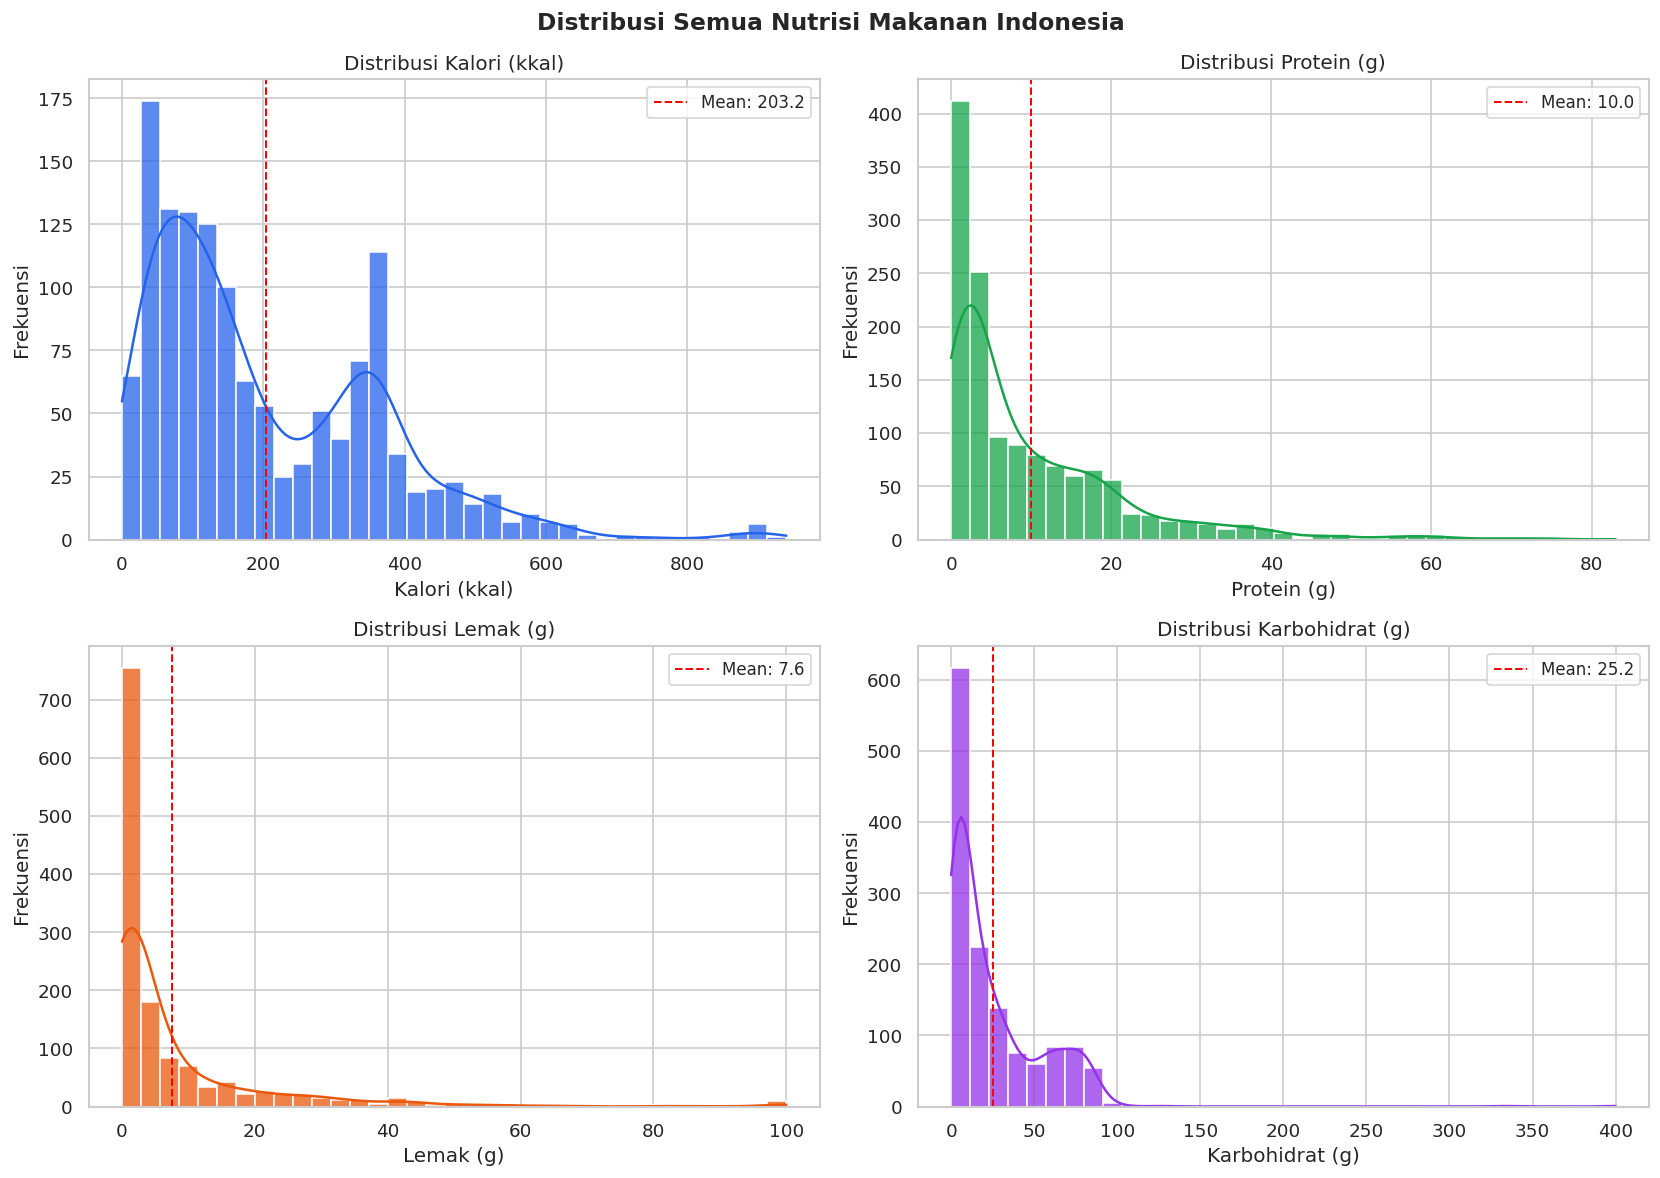

In [9]:
# Distribusi semua nutrisi
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribusi Semua Nutrisi Makanan Indonesia', fontsize=14, fontweight='bold')

nutrisi_config = [
    ('calories', 'Kalori (kkal)', '#2563EB', axes[0, 0]),
    ('proteins', 'Protein (g)', '#16A34A', axes[0, 1]),
    ('fat', 'Lemak (g)', '#EA580C', axes[1, 0]),
    ('carbohydrate', 'Karbohidrat (g)', '#9333EA', axes[1, 1]),
]

for col, label, color, ax in nutrisi_config:
    sns.histplot(df_clean[col], ax=ax, bins=35, color=color, alpha=0.75, kde=True)
    ax.set_xlabel(label)
    ax.set_ylabel('Frekuensi')
    ax.set_title(f'Distribusi {label}')
    ax.axvline(df_clean[col].mean(), color='red', linestyle='--', linewidth=1.2,
               label=f'Mean: {df_clean[col].mean():.1f}')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 📊 Distribusi Semua Nutrisi Makanan Indonesia

> Visualisasi ini melengkapi BQ1 dengan melihat distribusi **keempat nutrisi utama** secara bersamaan — kalori, protein, lemak, dan karbohidrat — untuk memahami profil gizi keseluruhan dataset.

---

### 🔵 1. Distribusi Kalori (Mean: 203,2 kkal)

Distribusi kalori menunjukkan pola **bimodal right-skewed**:
- **Puncak pertama** di kisaran 0–100 kkal → didominasi sayuran, buah, dan minuman rendah kalori
- **Puncak kedua** di kisaran 300–400 kkal → kelompok makanan olahan, gorengan, dan makanan berbahan dasar tepung
- Mean 203,2 kkal berada di antara dua puncak, menandakan distribusi yang tidak normal
- Ekor panjang hingga >800 kkal berasal dari makanan ekstrem seperti minyak goreng dan mentega

---

### 🟢 2. Distribusi Protein (Mean: 10,0 g)

Distribusi protein sangat **right-skewed ekstrem**:
- Mayoritas makanan memiliki protein sangat rendah (**0–5 g**), dengan frekuensi tertinggi di bar pertama (>400 item)
- Setelah 10g, frekuensi turun drastis — hanya sedikit makanan yang kaya protein
- Mean 10,0 g cukup tinggi karena ditarik oleh outlier makanan tinggi protein seperti ikan kering, tempe, dan putih telur (bisa mencapai 40–80g/100g)
- **Implikasi kolesterol:** Mayoritas makanan Indonesia tidak cukup tinggi protein, padahal protein penting untuk mengimbangi efek lemak

---

### 🟠 3. Distribusi Lemak (Mean: 7,6 g)

Distribusi lemak menunjukkan pola **paling ekstrem** di antara keempat nutrisi:
- Bar pertama (0–5 g) mendominasi dengan frekuensi >750 item — artinya **lebih dari separuh dataset** memiliki lemak sangat rendah
- Kurva KDE turun sangat curam, hampir menyentuh nol setelah 20g
- Namun ekor sangat panjang hingga 100g → ini adalah makanan seperti minyak kelapa sawit, santan kental, dan keju
- Mean 7,6 g berada jauh di kanan median yang diperkirakan sekitar 2–3 g — bukti outlier yang sangat mempengaruhi rata-rata
- **Implikasi kolesterol:** Kabar baiknya, sebagian besar makanan Indonesia rendah lemak secara absolut. Namun segelintir makanan berlemak sangat tinggi perlu diwaspadai

---

### 🟣 4. Distribusi Karbohidrat (Mean: 25,2 g)

Distribusi karbohidrat bersifat **right-skewed dengan plateau di tengah**:
- Puncak utama di 0–10 g (>600 item) — sayuran dan makanan protein tinggi
- Terdapat **plateau yang cukup rata** di rentang 10–100 g, menandakan banyak makanan tersebar merata di kisaran karbo sedang
- Mean 25,2 g lebih representatif dibanding nutrisi lain karena distribusinya lebih "menyebar"
- Ekor hingga 400 g berasal dari tepung, gula, dan makanan ringan berbasis karbohidrat murni

---

### 📋 Ringkasan Komparatif

| Nutrisi | Mean | Pola Distribusi | Skewness | Catatan untuk Kolesterol |
|---|---|---|---|---|
| Kalori | 203,2 kkal | Bimodal, right-skewed | Tinggi | Waspadai puncak kedua (300–400 kkal) |
| Protein | 10,0 g | Unimodal, right-skewed ekstrem | Sangat Tinggi | Mayoritas makanan rendah protein |
| Lemak | 7,6 g | Unimodal, right-skewed ekstrem | Paling Tinggi | Outlier lemak tinggi sangat berbahaya |
| Karbohidrat | 25,2 g | Right-skewed dengan plateau | Sedang | Relatif merata, perlu batasi >40g |

---

### 💡 Insight Gabungan

Keempat distribusi semuanya **right-skewed**, yang merupakan pola umum pada data nutrisi. Ini mengindikasikan:

1. **Dataset didominasi makanan "baik"** secara nutrisi (rendah lemak, rendah kalori) — namun outlier di ekor kanan inilah yang menjadi fokus utama Cholestify untuk diwaspadai
2. **Lemak memiliki distribusi paling tidak merata** — gap antara median dan mean paling besar, menandakan beberapa makanan memiliki kandungan lemak yang jauh di atas rata-rata
3. **Protein paling tidak merata kedua** — mayoritas makanan miskin protein, padahal protein tinggi adalah salah satu kriteria utama rekomendasi Cholestify

> 📌 **Kesimpulan:** Profil nutrisi makanan Indonesia secara umum cukup baik (mean lemak hanya 7,6 g), namun outlier berlemak tinggi dan rendah protein adalah target utama yang perlu diidentifikasi pada analisis BQ2 dan BQ4.

In [10]:
# BQ2 — Makanan tinggi lemak, rendah protein (berisiko kolesterol)
print('BQ2: Makanan Tinggi Lemak (>20g) & Rendah Protein (<5g):')
berisiko = df_clean[(df_clean['fat'] > 20) & (df_clean['proteins'] < 5)]
print(f'Jumlah: {len(berisiko)} makanan')
print(berisiko[['name', 'calories', 'fat', 'proteins', 'carbohydrate']]
      .sort_values('fat', ascending=False).head(20).to_string(index=False))

BQ2: Makanan Tinggi Lemak (>20g) & Rendah Protein (<5g):
Jumlah: 36 makanan
                     name  calories   fat  proteins  carbohydrate
      Minyak Kelapa Sawit     902.0 100.0       0.0           0.0
            Minyak Zaitun     884.0 100.0       0.0           0.0
      Minyak Kacang Tanah     902.0 100.0       0.0           0.0
               Lemak Babi     902.0 100.0       0.0           0.0
             Minyak Wijen     902.0 100.0       0.0           0.0
Minyak Hati Hiu (Eulamia)     902.0 100.0       0.0           0.0
              Minyak Ikan     902.0 100.0       0.0           0.0
           Minyak Kedelai     883.0  99.9       0.0           0.0
            Minyak Kelapa     870.0  98.0       1.0           0.0
             Lemak Kerbau     818.0  90.0       1.5           0.0
                  Mentega     725.0  81.6       0.5           1.4
                 Margarin     720.0  81.0       0.6           0.4
                    Bubur      60.0  60.0       1.0          13.0


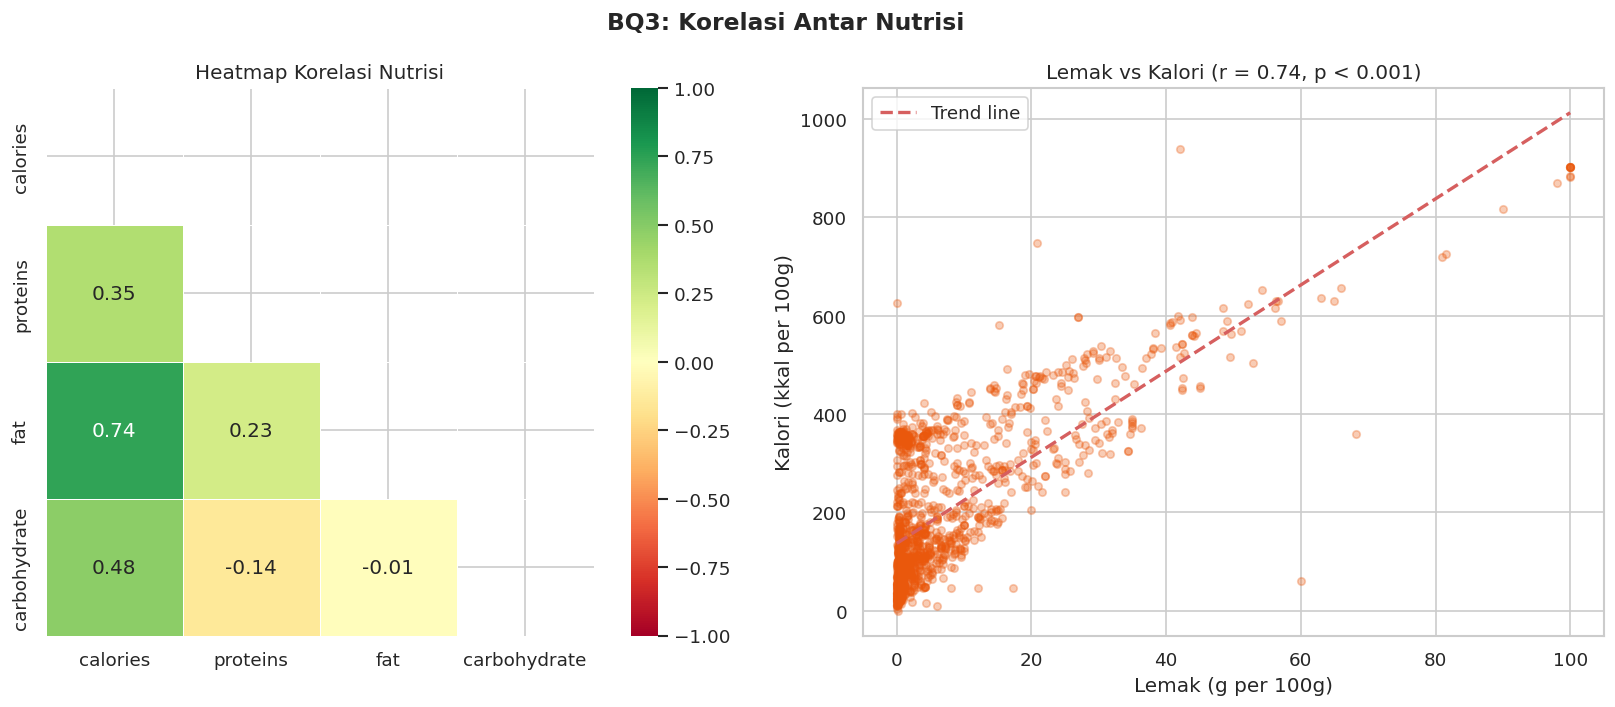

 Korelasi Lemak-Kalori: r = 0.738 (sangat kuat, positif)


In [11]:
# BQ3 — Korelasi Nutrisi
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('BQ3: Korelasi Antar Nutrisi', fontsize=14, fontweight='bold')

# Define numeric columns for correlation
numeric_cols = ['calories', 'proteins', 'fat', 'carbohydrate']

# Heatmap korelasi
corr_matrix = df_clean[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=axes[0], mask=mask, vmin=-1, vmax=1,
            linewidths=0.5, square=True, annot_kws={'size': 12})
axes[0].set_title('Heatmap Korelasi Nutrisi')

# Scatter plot lemak vs kalori
axes[1].scatter(df_clean['fat'], df_clean['calories'], alpha=0.3, color='#EA580C', s=20)
# Trend line
z = np.polyfit(df_clean['fat'], df_clean['calories'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_clean['fat'].min(), df_clean['fat'].max(), 100)
axes[1].plot(x_line, p(x_line), 'r--', linewidth=2, label='Trend line')
r, pval = stats.pearsonr(df_clean['fat'], df_clean['calories'])
axes[1].set_xlabel('Lemak (g per 100g)')
axes[1].set_ylabel('Kalori (kkal per 100g)')
axes[1].set_title(f'Lemak vs Kalori (r = {r:.2f}, p < 0.001)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f' Korelasi Lemak-Kalori: r = {r:.3f} (sangat kuat, positif)')

## 📊 BQ3 — Korelasi Antara Kandungan Lemak dan Kalori

> **Business Question:** Apakah ada korelasi antara kandungan lemak dan kalori pada makanan Indonesia?

---

### 🔥 Heatmap Korelasi Antar Nutrisi

Heatmap menampilkan korelasi Pearson antara keempat nutrisi utama (hanya segitiga bawah ditampilkan untuk menghindari duplikasi):

| Pasangan Nutrisi | Nilai r | Interpretasi | Kekuatan |
|---|---|---|---|
| **Fat → Calories** | **0,74** | Positif kuat | 🟢 Kuat |
| Carbohydrate → Calories | 0,48 | Positif sedang | 🟡 Sedang |
| Proteins → Calories | 0,35 | Positif lemah-sedang | 🟡 Lemah-Sedang |
| Proteins → Fat | 0,23 | Positif sangat lemah | ⚪ Lemah |
| Carbohydrate → Proteins | -0,14 | Negatif sangat lemah | ⚪ Hampir nol |
| Carbohydrate → Fat | -0,01 | Tidak berkorelasi | ⚪ Nol |

**Temuan kunci dari heatmap:**
- **Lemak adalah prediktor terkuat kalori** (r = 0,74) di antara semua nutrisi
- Karbohidrat berkorelasi sedang dengan kalori (r = 0,48) — kontribusinya nyata tapi jauh di bawah lemak
- Karbohidrat dan lemak hampir **tidak berkorelasi sama sekali** (r = -0,01), artinya makanan tinggi karbo belum tentu tinggi lemak dan sebaliknya — keduanya merupakan sumber kalori yang **independen**
- Protein dan karbohidrat berkorelasi negatif lemah (r = -0,14) — makanan tinggi protein cenderung sedikit lebih rendah karbohidrat, konsisten dengan makanan seperti ikan dan daging

---

### 📈 Scatter Plot: Lemak vs Kalori (r = 0,74, p < 0,001)

Scatter plot memperkuat temuan heatmap dengan beberapa pola visual yang jelas:

**1. Pola kerucut (heteroskedastisitas)**
Titik-titik membentuk pola **melebar ke kanan** — pada lemak rendah (0–10g), sebaran kalori sangat padat dan bervariasi lebar (0–600 kkal). Ini menunjukkan bahwa pada makanan rendah lemak, kalori bisa berasal dari protein atau karbohidrat yang bervariasi.

**2. Trend line positif yang jelas**
Garis regresi naik secara konsisten dari kiri bawah ke kanan atas, mengkonfirmasi hubungan positif yang kuat. Setiap penambahan lemak **~9 kkal per gram** secara teoretis (lemak = 9 kkal/g) tercermin dalam kemiringan garis ini.

**3. Kluster padat di pojok kiri bawah**
Sebagian besar data terkonsentrasi di area lemak 0–20g dan kalori 0–400 kkal — konsisten dengan temuan distribusi sebelumnya bahwa mayoritas makanan Indonesia rendah lemak.

**4. Outlier di pojok kanan atas**
Beberapa titik ekstrem di kisaran lemak >60g dan kalori >800 kkal — kemungkinan besar adalah **minyak goreng, mentega, margarin, dan santan pekat**. Titik-titik ini tidak banyak jumlahnya namun berkontribusi signifikan pada kekuatan korelasi.

**5. Signifikansi statistik (p < 0,001)**
Nilai p jauh di bawah 0,05, artinya korelasi ini **bukan kebetulan** — hubungan lemak-kalori terbukti secara statistik pada dataset 1.345 makanan ini.

---

### 💡 Jawaban Business Question

**Ya, terdapat korelasi positif yang kuat (r = 0,74, p < 0,001) antara kandungan lemak dan kalori.** Ini berarti:

1. **Lemak adalah penyumbang kalori terbesar** dibanding protein maupun karbohidrat — secara biokimia memang benar karena 1g lemak = 9 kkal, sedangkan protein dan karbo hanya 4 kkal/g

2. **Implikasi untuk Cholestify:** Mengurangi makanan berlemak secara otomatis akan menurunkan asupan kalori secara signifikan — dua masalah sekaligus terselesaikan dengan satu filter

3. **Karbohidrat dan lemak independen (r = -0,01):** Tidak bisa mengandalkan "rendah karbo = rendah lemak". Keduanya harus dipantau secara terpisah dalam sistem rekomendasi

4. **Protein tidak cukup kuat (r = 0,35):** Makanan tinggi protein tidak selalu tinggi kalori, menjadikannya **kandidat ideal** untuk direkomendasikan — tinggi protein tapi tidak membebani kalori dan lemak

---

> 📌 **Kesimpulan BQ3:** Lemak adalah nutrisi yang paling menentukan tinggi-rendahnya kalori suatu makanan (r = 0,74). Temuan ini menjadi landasan ilmiah bagi sistem rekomendasi Cholestify untuk menjadikan **kandungan lemak sebagai filter utama (bobot 40%)** dalam skor rekomendasi di BQ5.

## 📊 BQ2 — Makanan Tinggi Lemak (>20g) & Rendah Protein (<5g)

### Business Question

Makanan apa saja yang memiliki kandungan lemak tinggi (>20g) sekaligus rendah protein (<5g), dan bagaimana karakteristik serta pola distribusinya dalam dataset makanan Indonesia?

---

## 🔍 Hasil Filter

Dari total **1.345 makanan** dalam dataset, ditemukan **36 makanan (2,7%)** yang memenuhi kriteria:

* Lemak >20g
* Protein <5g

Meskipun jumlahnya kecil, kelompok makanan ini memberikan pengaruh besar terhadap distribusi lemak dan kalori dalam dataset. Kelompok ini menjadi penyebab utama munculnya *right-tail distribution* atau ekor kanan ekstrem pada analisis distribusi sebelumnya.

---

## 🔴 Tier 1 — Sangat Berbahaya (Lemak >80g)

Kategori ini berisi makanan dengan kandungan lemak paling ekstrem dalam dataset.

### Karakteristik

* Didominasi oleh berbagai jenis minyak:

  * Minyak Kelapa Sawit
  * Minyak Zaitun
  * Minyak Kacang Tanah
  * Minyak Wijen
  * Minyak Ikan
  * Minyak Hati Hiu
  * Minyak Kedelai
* Lemak hewani seperti:

  * Lemak Babi
  * Lemak Kerbau
* Produk olahan:

  * Mentega
  * Margarin

### Temuan Utama

* Kandungan lemak berada pada rentang **81–100g**
* Kalori mencapai sekitar **720–900 kkal per 100g**
* Protein hampir nol (**0–1,5g**)

Artinya, makanan pada tier ini hampir sepenuhnya terdiri dari lemak dan kalori tanpa kontribusi protein yang signifikan.

### Implikasi

Kelompok ini dapat dikategorikan sebagai *blacklist* untuk penderita kolesterol tinggi. Sebagai contoh, 1 sendok makan minyak goreng (~14g) sudah menyumbang sekitar 13g lemak atau hampir setengah batas konsumsi lemak harian yang direkomendasikan (~30g/hari).

---

## 🟠 Tier 2 — Berbahaya (Lemak 40–80g)

Kelompok ini lebih beragam, tetapi tetap memiliki risiko tinggi.

### Karakteristik

Beberapa makanan yang termasuk:

* Kelapa Hutan Kering
* Keripik Bayam
* Bubur (anomali data)

### Temuan Utama

* Lemak berada pada rentang **40–80g**
* Kalori rata-rata sekitar **486 kkal**
* Protein tetap rendah (**1,9g rata-rata**)

### Anomali Data

Data “Bubur” menunjukkan:

* Lemak = 60g
* Kalori = 60 kkal

Nilai ini tidak konsisten secara biokimia karena 60g lemak seharusnya menghasilkan minimal sekitar 540 kkal. Oleh karena itu, data ini perlu diverifikasi atau dikeluarkan dari analisis lanjutan.

### Implikasi

Keripik goreng dan produk kelapa kering sering dianggap camilan tradisional atau alami, padahal kandungan lemaknya sangat tinggi dan mendekati produk berbasis mentega.

---

## 🟡 Tier 3 — Waspada (Lemak 20–40g)

Tier ini merupakan kelompok terbesar dan paling relevan dalam konsumsi sehari-hari masyarakat Indonesia.

### Karakteristik

Makanan yang termasuk antara lain:

* Santan Murni
* Santan Kelapa
* Kelapa Tua Daging
* Coklat Manis Batang
* Bagea Kenari Asin

### Temuan Utama

* Lemak berada pada rentang **20–40g**
* Kalori rata-rata sekitar **405 kkal**
* Protein rata-rata hanya **2,6g**
* Karbohidrat relatif tinggi dibanding tier lainnya

Hal ini menunjukkan adanya kombinasi:

* tinggi lemak
* tinggi karbohidrat
* rendah protein

### Implikasi

Santan menjadi perhatian utama karena digunakan dalam banyak makanan khas Indonesia seperti rendang, opor, lodeh, dan kolak. Konsumsi santan dalam satu porsi masakan dapat menyumbang 20–30g lemak sebelum ditambah bahan lain.

---

## 📋 Ringkasan Komparatif

| Tier             | Jumlah  | Rentang Lemak | Kalori Rata-rata | Protein Rata-rata | Contoh                        |
| ---------------- | ------- | ------------- | ---------------- | ----------------- | ----------------------------- |
| Sangat Berbahaya | 12      | 81–100g       | 797 kkal         | 0,4g              | Minyak goreng, mentega        |
| Berbahaya        | 8       | 40–80g        | 486 kkal         | 1,9g              | Keripik goreng, kelapa kering |
| Waspada          | 16      | 20–40g        | 405 kkal         | 2,6g              | Santan, coklat                |
| **Total BQ2**    | **36**  | **>20g**      | **656 kkal**     | **1,8g**          | —                             |
| *Dataset penuh*  | *1.345* | *0–100g*      | *203 kkal*       | *10,0g*           | —                             |

---

## 💡 Insight Utama

### 1. Outlier Penggerak Mean

Perbedaan besar antara:

* mean lemak dataset = 7,6g
* median lemak ≈ 2–3g

menunjukkan adanya distorsi distribusi yang sebagian besar disebabkan oleh 36 makanan BQ2 ini.

---

### 2. Paradoks “Makanan Tradisional”

Beberapa makanan tradisional seperti:

* santan
* kelapa
* keripik sayur

sering dianggap sehat karena alami, namun kandungan lemaknya sangat tinggi dan dapat menyaingi makanan cepat saji modern.

---

### 3. Kontributor Utama Korelasi Lemak vs Kalori

Kelompok BQ2 menjadi titik ekstrem pada scatter plot lemak vs kalori dan memperkuat korelasi positif antar keduanya.

---

### 4. Deteksi Anomali Dataset

Ditemukannya data tidak konsisten seperti “Bubur” menunjukkan pentingnya proses validasi data sebelum model rekomendasi Cholestify digunakan secara produksi.

---

## 📌 Kesimpulan

Sebanyak **36 makanan tinggi lemak dan rendah protein** berhasil diidentifikasi dan dibagi menjadi tiga tier risiko utama:

* **Tier 1:** makanan yang sebaiknya dihindari (*blacklist*)
* **Tier 2:** makanan yang perlu dibatasi secara ketat
* **Tier 3:** makanan yang memerlukan edukasi porsi konsumsi

Hasil analisis ini menunjukkan bahwa makanan tradisional dan bahan masakan sehari-hari dapat menjadi sumber lemak tinggi tersembunyi. Oleh karena itu, Cholestify perlu menerapkan strategi edukasi konsumsi yang disesuaikan dengan tingkat risiko masing-masing kategori makanan.


---
## 7. Explanatory Analysis & Visualisasi
> Menjawab business questions dengan visualisasi yang komunikatif.

Distribusi Kategori Makanan:
kategori
Sedang                          370
Rendah Lemak                    309
Rendah Lemak & Karbo            301
Tinggi Protein, Rendah Lemak    157
Tinggi Protein & Lemak          108
Tinggi Lemak                    101
Name: count, dtype: int64


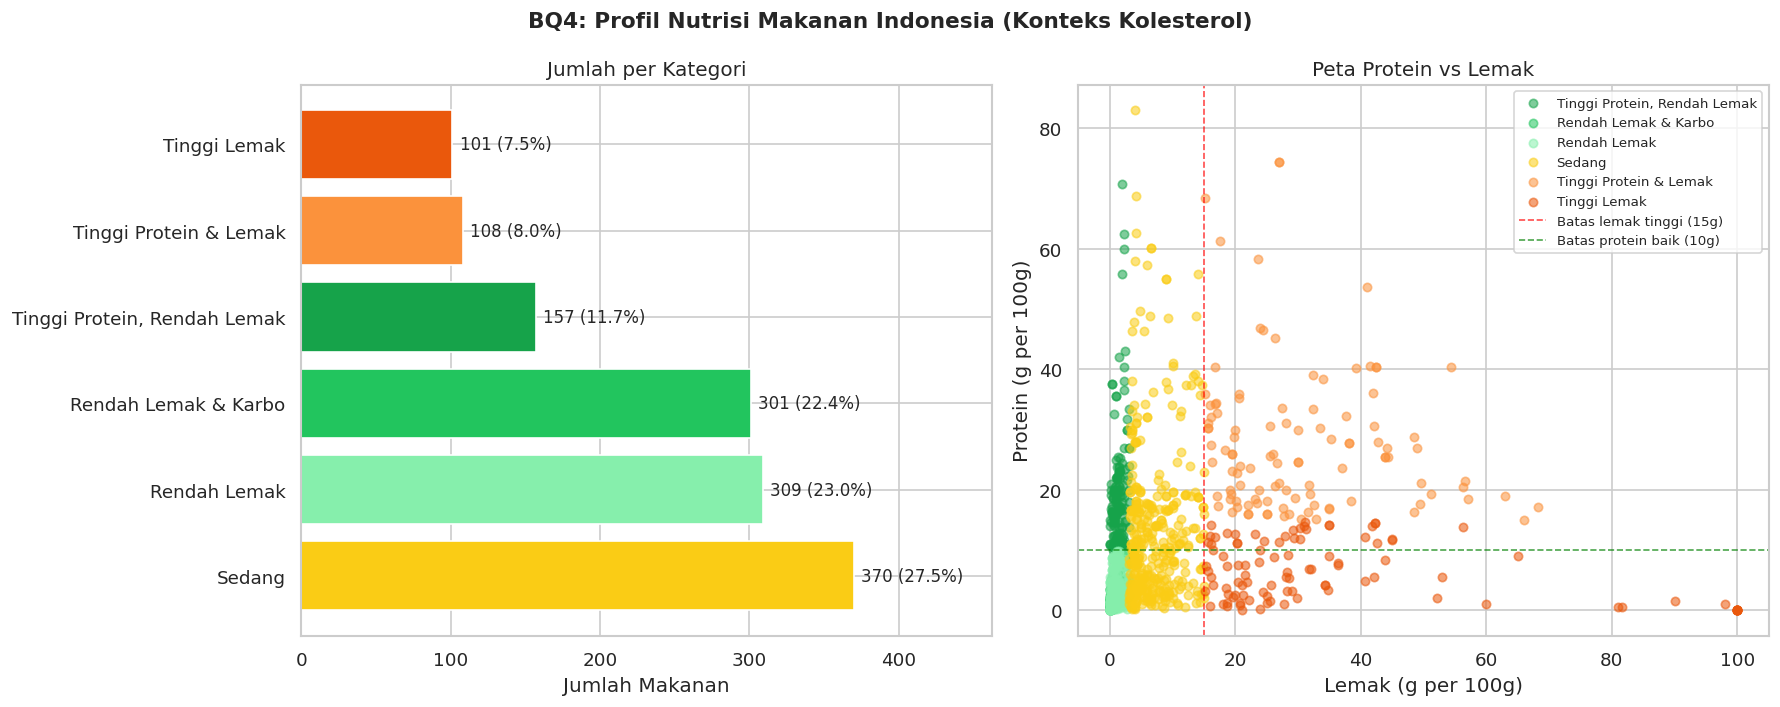

In [12]:
# BQ4 — Kategorisasi makanan berdasarkan profil nutrisi

def kategorisasi_makanan(row):
    """Klasifikasi makanan berdasarkan profil nutrisi untuk konteks kolesterol."""
    if row['fat'] <= 3 and row['proteins'] >= 10:
        return 'Tinggi Protein, Rendah Lemak'    # Ideal
    elif row['fat'] <= 3 and row['carbohydrate'] <= 15:
        return 'Rendah Lemak & Karbo'             # Sangat Baik
    elif row['fat'] <= 3:
        return 'Rendah Lemak'                     # Baik
    elif row['fat'] > 15 and row['proteins'] >= 15:
        return 'Tinggi Protein & Lemak'           # Sedang (perlu porsi)
    elif row['fat'] > 15:
        return 'Tinggi Lemak'                     # Perlu Dibatasi
    else:
        return 'Sedang'

df_clean['kategori'] = df_clean.apply(kategorisasi_makanan, axis=1)

kategori_count = df_clean['kategori'].value_counts()
print('Distribusi Kategori Makanan:')
print(kategori_count)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('BQ4: Profil Nutrisi Makanan Indonesia (Konteks Kolesterol)',
             fontsize=13, fontweight='bold')

# Bar chart
palette = {'Tinggi Protein, Rendah Lemak': '#16A34A',
           'Rendah Lemak & Karbo': '#22C55E',
           'Rendah Lemak': '#86EFAC',
           'Sedang': '#FACC15',
           'Tinggi Protein & Lemak': '#FB923C',
           'Tinggi Lemak': '#EA580C'}

colors_bar = [palette.get(k, '#9CA3AF') for k in kategori_count.index]
bars = axes[0].barh(kategori_count.index, kategori_count.values,
                    color=colors_bar, edgecolor='white')
for bar, val in zip(bars, kategori_count.values):
    axes[0].text(val + 5, bar.get_y() + bar.get_height()/2,
                f'{val} ({val/len(df_clean)*100:.1f}%)',
                va='center', fontsize=10)
axes[0].set_xlabel('Jumlah Makanan')
axes[0].set_title('Jumlah per Kategori')
axes[0].set_xlim(0, kategori_count.max() * 1.25)

# Scatter plot protein vs lemak dengan warna kategori
for kategori, color in palette.items():
    subset = df_clean[df_clean['kategori'] == kategori]
    if len(subset) > 0:
        axes[1].scatter(subset['fat'], subset['proteins'],
                        label=kategori, color=color, alpha=0.55, s=25)
axes[1].axvline(x=15, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Batas lemak tinggi (15g)')
axes[1].axhline(y=10, color='green', linestyle='--', linewidth=1, alpha=0.7, label='Batas protein baik (10g)')
axes[1].set_xlabel('Lemak (g per 100g)')
axes[1].set_ylabel('Protein (g per 100g)')
axes[1].set_title('Peta Protein vs Lemak')
axes[1].legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

## 📊 BQ4 — Distribusi Kategori Makanan Berdasarkan Profil Nutrisi

> **Business Question:** Bagaimana distribusi kategori makanan berdasarkan profil nutrisi (tinggi protein, rendah lemak, dll)?

---

### 🏷️ Logika Kategorisasi

Setiap makanan diklasifikasikan menggunakan fungsi `kategorisasi_makanan()` dengan aturan berbasis threshold lemak dan protein:

| Kategori | Kondisi | Status Kolesterol |
|---|---|---|
| 🟢 **Tinggi Protein, Rendah Lemak** | fat ≤ 3g **AND** protein ≥ 10g | ✅ Ideal |
| 🟢 **Rendah Lemak & Karbo** | fat ≤ 3g **AND** karbo ≤ 15g | ✅ Sangat Baik |
| 🟢 **Rendah Lemak** | fat ≤ 3g | ✅ Baik |
| 🟡 **Sedang** | 3g < fat ≤ 15g | ⚠️ Perhatikan Porsi |
| 🟠 **Tinggi Protein & Lemak** | fat > 15g **AND** protein ≥ 15g | ⚠️ Batasi Porsi |
| 🔴 **Tinggi Lemak** | fat > 15g | ❌ Perlu Dihindari |

---

### 📊 Distribusi Kategori (Bar Chart)

| # | Kategori | Jumlah | Persentase | Interpretasi |
|---|---|---|---|---|
| 1 | 🟡 Sedang | 370 | 27,5% | Kelompok terbesar — lemak 3–15g, perlu kontrol porsi |
| 2 | 🟢 Rendah Lemak | 309 | 23,0% | Aman dikonsumsi, namun perlu cek protein |
| 3 | 🟢 Rendah Lemak & Karbo | 301 | 22,4% | Pilihan sangat baik — rendah lemak sekaligus rendah karbo |
| 4 | 🟢 Tinggi Protein, Rendah Lemak | 157 | 11,7% | **Kategori ideal** untuk penderita kolesterol |
| 5 | 🟠 Tinggi Protein & Lemak | 108 | 8,0% | Manfaat protein ada, tapi lemak tetap perlu dibatasi |
| 6 | 🔴 Tinggi Lemak | 101 | 7,5% | Harus dihindari penderita kolesterol |

---

### 🗺️ Peta Protein vs Lemak (Scatter Plot)

Scatter plot membagi ruang menjadi **4 kuadran** yang dibatasi oleh garis merah (lemak = 15g) dan garis hijau (protein = 10g):

**Kuadran Kiri Atas — Lemak < 15g & Protein > 10g** ✅
Titik-titik hijau tua (*Tinggi Protein, Rendah Lemak*) terkonsentrasi di sini. Ini adalah **zona emas** — makanan ideal untuk penderita kolesterol. Contohnya ikan rebus, ayam tanpa kulit, tempe, dan tahu.

**Kuadran Kiri Bawah — Lemak < 15g & Protein < 10g** ✅
Didominasi titik hijau muda (*Rendah Lemak* dan *Rendah Lemak & Karbo*) dan kuning (*Sedang*). Kluster paling padat ada di pojok kiri bawah (lemak 0–5g, protein 0–10g) — ini adalah sayuran, buah, dan minuman.

**Kuadran Kanan Atas — Lemak > 15g & Protein > 10g** ⚠️
Titik oranye (*Tinggi Protein & Lemak*) tersebar di sini. Masih ada nilai protein yang kompensatif, namun porsi harus dikendalikan ketat. Contoh: daging merah, ikan asin, keju.

**Kuadran Kanan Bawah — Lemak > 15g & Protein < 10g** ❌
Titik merah-oranye gelap (*Tinggi Lemak*) tersebar di sini — zona paling berbahaya untuk kolesterol. Lemak tinggi tanpa manfaat protein. Contoh: gorengan, santan kental, minyak, makanan ringan berlemak.

---

### 💡 Jawaban Business Question

**57,1%** makanan Indonesia masuk kategori aman (Rendah Lemak + Rendah Lemak & Karbo + Tinggi Protein Rendah Lemak), namun distribusinya tidak merata:

**1. Kategori "Sedang" mendominasi (27,5%)**
Ini adalah kelompok abu-abu yang paling perlu diperhatikan — lemak 3–15g per 100g masih dalam batas, namun jika dikonsumsi dalam porsi besar atau kombinasi banyak makanan sedang sekaligus, total asupan lemak harian bisa melampaui batas aman (≤65g/hari berdasarkan AHA).

**2. Kategori ideal hanya 11,7%**
Makanan *Tinggi Protein, Rendah Lemak* yang benar-benar ideal hanya 157 dari 1.345 makanan — ini menjadi **pool utama rekomendasi Cholestify** di BQ5.

**3. Kombinasi kategori hijau mencapai 57,1%**
Jika tiga kategori hijau digabung (Tinggi Protein Rendah Lemak + Rendah Lemak & Karbo + Rendah Lemak), penderita kolesterol masih punya **768 pilihan makanan** yang relatif aman — lebih dari separuh dataset.

**4. Hanya 15,5% yang perlu diwaspadai serius**
Kategori *Tinggi Lemak* (7,5%) dan *Tinggi Protein & Lemak* (8,0%) berjumlah 209 makanan — ini adalah daftar makanan yang perlu dibatasi atau dihindari dalam aplikasi Cholestify.

---

> 📌 **Kesimpulan BQ4:** Mayoritas makanan Indonesia (57,1%) masuk kategori profil nutrisi yang aman untuk kolesterol, dengan 11,7% masuk kategori ideal (*Tinggi Protein, Rendah Lemak*). Namun kelompok *Sedang* yang mendominasi (27,5%) menjadi tantangan tersendiri karena statusnya bergantung pada kontrol porsi. Temuan ini menjadi dasar penentuan kandidat makanan yang direkomendasikan pada BQ5.

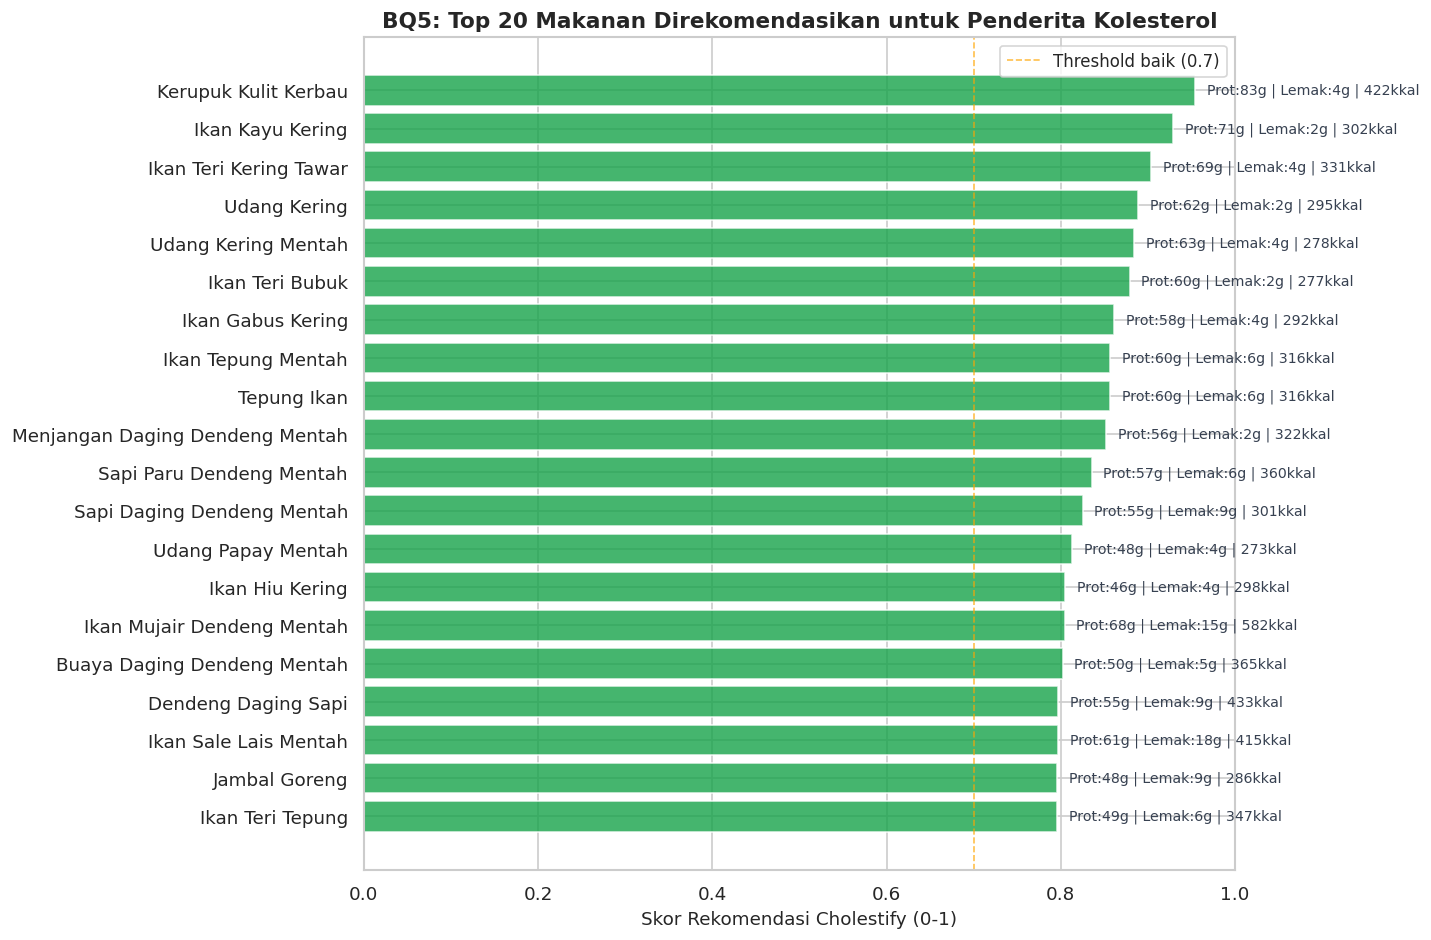


 Top 10 Makanan Terbaik:
                           name  calories  proteins  fat  carbohydrate  rekomendasi_score
           Kerupuk Kulit Kerbau     422.0      83.0  4.0           0.0             0.9542
               Ikan Kayu Kering     302.0      70.7  1.9           0.4             0.9289
         Ikan Teri Kering Tawar     331.0      68.7  4.2           0.0             0.9039
                   Udang Kering     295.0      62.4  2.3           1.8             0.8888
            Udang Kering Mentah     278.0      62.6  4.1           2.2             0.8844
                Ikan Teri Bubuk     277.0      60.0  2.3           1.8             0.8789
              Ikan Gabus Kering     292.0      58.0  4.0           0.0             0.8614
             Ikan Tepung Mentah     316.0      60.1  6.5          22.4             0.8564
                    Tepung Ikan     316.0      60.1  6.5          22.4             0.8564
Menjangan Daging Dendeng Mentah     322.0      55.8  2.0          22.7    

In [13]:
# BQ5 — Top 20 makanan terbaik untuk penderita kolesterol
# Kriteria: rendah lemak, cukup protein, kalori sedang

# Normalisasi skor (0-1)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

df_score = df_clean.copy()
df_score['fat_norm'] = scaler.fit_transform(df_score[['fat']])
df_score['protein_norm'] = scaler.fit_transform(df_score[['proteins']])
df_score['cal_norm'] = scaler.fit_transform(df_score[['calories']])

# Skor rekomendasi: tinggi protein, rendah lemak, kalori sedang
df_score['rekomendasi_score'] = (
    0.4 * df_score['protein_norm'] +
    0.4 * (1 - df_score['fat_norm']) +
    0.2 * (1 - abs(df_score['cal_norm'] - 0.3))
).round(4)

top20 = df_score.nlargest(20, 'rekomendasi_score')[['name','calories','proteins','fat','carbohydrate','rekomendasi_score']]

# Visualisasi
fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top20['name'][::-1], top20['rekomendasi_score'][::-1],
               color='#16A34A', alpha=0.8, edgecolor='white')
for bar, (_, row) in zip(bars, top20[::-1].iterrows()):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'  Prot:{row["proteins"]:.0f}g | Lemak:{row["fat"]:.0f}g | {row["calories"]:.0f}kkal',
            va='center', fontsize=8.5, color='#374151')
ax.set_xlabel('Skor Rekomendasi Cholestify (0-1)', fontsize=11)
ax.set_title('BQ5: Top 20 Makanan Direkomendasikan untuk Penderita Kolesterol',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.0)
ax.axvline(0.7, color='orange', linestyle='--', linewidth=1, alpha=0.7, label='Threshold baik (0.7)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('\n Top 10 Makanan Terbaik:')
print(top20[['name','calories','proteins','fat','carbohydrate','rekomendasi_score']].head(10).to_string(index=False))

## 📊 BQ5 — Makanan Paling Direkomendasikan untuk Penderita Kolesterol Tinggi

> **Business Question:** Makanan apa yang paling direkomendasikan untuk penderita kolesterol tinggi (rendah lemak, cukup protein)?

---

### ⚙️ Metodologi: Sistem Skoring Cholestify

Setiap makanan diberi **skor rekomendasi 0–1** menggunakan formula berbobot berbasis 3 komponen yang dinormalisasi dengan MinMaxScaler:

```python
rekomendasi_score = (
    0.4 × protein_norm          # Makin tinggi protein → makin baik
  + 0.4 × (1 - fat_norm)        # Makin rendah lemak  → makin baik
  + 0.2 × (1 - |cal_norm - 0.3|) # Kalori mendekati sedang → makin baik
)
```

| Komponen | Bobot | Alasan |
|---|---|---|
| Protein (tinggi) | 40% | Protein membantu menjaga massa otot & rasa kenyang tanpa meningkatkan kolesterol |
| Lemak (rendah) | 40% | Lemak adalah prediktor kolesterol terkuat (r = 0,74 dari BQ3) |
| Kalori (sedang) | 20% | Kalori ekstrem (terlalu rendah/tinggi) kurang ideal untuk konsumsi harian |

> Threshold skor "baik" ditetapkan di **≥ 0,7** — semua Top 20 melampaui threshold ini.

---

### 🏆 Top 20 Makanan Terbaik — Analisis Detail

#### 🥇 Peringkat 1–5: Elite Tier (Skor ≥ 0,88)

| Peringkat | Makanan | Protein | Lemak | Kalori | Skor |
|---|---|---|---|---|---|
| 1 | Kerupuk Kulit Kerbau | 83g | 4g | 422 kkal | 0,9542 |
| 2 | Ikan Kayu Kering | 71g | 2g | 302 kkal | 0,9289 |
| 3 | Ikan Teri Kering Tawar | 69g | 4g | 331 kkal | 0,9039 |
| 4 | Udang Kering | 62g | 2g | 295 kkal | 0,8888 |
| 5 | Udang Kering Mentah | 63g | 4g | 278 kkal | 0,8844 |

Kelima makanan ini memiliki **protein sangat tinggi (62–83g/100g)** dengan lemak yang sangat rendah (2–4g) — kombinasi ideal yang langka. Dominasi produk **kering/dehidrasi** karena proses pengeringan mengkonsentrasikan protein sekaligus menghilangkan kadar air dan lemak.

---

#### 🥈 Peringkat 6–10: Premium Tier (Skor 0,85–0,88)

| Peringkat | Makanan | Protein | Lemak | Kalori | Skor |
|---|---|---|---|---|---|
| 6 | Ikan Teri Bubuk | 60g | 2g | 277 kkal | 0,8789 |
| 7 | Ikan Gabus Kering | 58g | 4g | 292 kkal | 0,8614 |
| 8 | Ikan Tepung Mentah | 60g | 7g | 316 kkal | 0,8564 |
| 9 | Tepung Ikan | 60g | 7g | 316 kkal | 0,8564 |
| 10 | Menjangan Daging Dendeng Mentah | 56g | 2g | 323 kkal | 0,8524 |

---

#### 🥉 Peringkat 11–20: Good Tier (Skor ≥ 0,7)

| Peringkat | Makanan | Protein | Lemak | Kalori | Catatan |
|---|---|---|---|---|---|
| 11 | Sapi Paru Dendeng Mentah | 57g | 6g | 360 kkal | Jeroan, konsumsi terbatas |
| 12 | Sapi Daging Dendeng Mentah | 55g | 9g | 301 kkal | Lemak mulai naik |
| 13 | Udang Papay Mentah | 48g | 4g | 273 kkal | Segar, protein cukup baik |
| 14 | Ikan Hiu Kering | 46g | 4g | 298 kkal | Protein solid |
| 15 | Ikan Mujair Dendeng Mentah | 68g | 15g | 582 kkal | ⚠️ Lemak & kalori tinggi |
| 16 | Buaya Daging Dendeng Mentah | 50g | 5g | 365 kkal | Kalori agak tinggi |
| 17 | Dendeng Daging Sapi | 55g | 9g | 433 kkal | Kalori perlu diperhatikan |
| 18 | Ikan Sale Lais Mentah | 61g | 18g | 415 kkal | ⚠️ Lemak tertinggi di top 20 |
| 19 | Jambal Goreng | 48g | 9g | 286 kkal | Proses goreng, cek minyak |
| 20 | Ikan Teri Tepung | 49g | 6g | 347 kkal | Seimbang |

---

### 🔍 Pola & Insight dari Top 20

**1. Dominasi produk olahan kering (75% dari Top 20)**
Proses pengeringan/dehidrasi mengkonsentrasikan protein secara dramatis — dari ~20–30g pada ikan segar menjadi 55–83g per 100g. Ini bukan berarti lebih sehat secara absolut (kandungan garam bisa tinggi), namun secara skor nutrisi protein-lemak sangat unggul.

**2. Semua dari sumber hewani**
Tidak ada makanan nabati di Top 20 — ini karena protein hewani umumnya lebih dense dibanding nabati. Makanan nabati tinggi protein seperti tempe (~20g) dan tahu (~8g) tidak mampu bersaing secara skor dengan ikan/udang kering (55–83g).

**3. Dua pengecualian yang perlu dicatat ⚠️**
- **Ikan Sale Lais Mentah (peringkat 18):** Lemak 18g/100g — satu-satunya yang melampaui threshold "Tinggi Lemak" (>15g) dari BQ4. Masuk Top 20 karena proteinnya sangat tinggi (61g) yang mengkompensasi skor lemak.
- **Ikan Mujair Dendeng Mentah (peringkat 15):** Kalori 582 kkal — tertinggi di Top 20. Cocok untuk pasien yang butuh protein tinggi namun perlu kontrol porsi ketat.

**4. Rentang kalori yang beragam (273–582 kkal)**
Meski semua lolos threshold skor 0,7, kalorinya cukup bervariasi. Untuk penderita kolesterol yang juga mengontrol berat badan, prioritaskan peringkat 4–6 (Udang Kering, Udang Kering Mentah, Ikan Teri Bubuk) yang memiliki kalori paling rendah di Top 20.

---

### 💡 Jawaban Business Question

**Makanan yang paling direkomendasikan untuk penderita kolesterol tinggi adalah produk ikan dan udang kering**, dipimpin oleh Kerupuk Kulit Kerbau (skor 0,95), Ikan Kayu Kering (0,93), dan Ikan Teri Kering Tawar (0,90).

Rekomendasi praktis berdasarkan temuan ini:

- **Prioritas utama:** Ikan dan udang kering/bubuk — protein sangat tinggi, lemak sangat rendah
- **Alternatif segar:** Udang Papay dan Ikan Hiu (peringkat 13–14) dengan profil serupa namun lebih rendah kalori
- **Perhatikan dua hal:** (1) Kadar garam produk kering yang umumnya tinggi — tetap batasi jika ada hipertensi. (2) Makanan dendeng mentah di daftar ini belum dimasak — profil nutrisi bisa berubah setelah proses memasak

---

> 📌 **Kesimpulan BQ5:** Sistem skoring Cholestify berhasil mengidentifikasi **20 makanan teratas** dengan rasio protein-lemak terbaik, semuanya melampaui threshold skor 0,7. Produk ikan/udang kering mendominasi karena efisiensi protein yang sangat tinggi. Skor ini menjadi dasar engine rekomendasi Cholestify, yang selanjutnya akan diPersonalisasi berdasarkan nilai HDL & LDL pengguna secara individual (lihat bagian *Food Recommendation Logic*).

---
## 8. A/B Testing
> **Tujuan:** Menguji secara statistik efektivitas dua strategi filter rekomendasi makanan aman untuk penderita kolesterol.
> Menggunakan `df_clean` (data yang sudah dibersihkan) sebagai basis pengujian.


In [14]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu

# Grup A (Control)  : Filter kalori rendah → kalori < 100 kkal
# Grup B (Treatment): Filter lemak rendah + protein cukup
#                     → fat < 3 g DAN proteins >= 5g

grup_a = df_clean[df_clean["calories"] < 100]["fat"]
grup_b = df_clean[(df_clean["fat"] < 3) & (df_clean["proteins"] >= 5)]["fat"]

ALPHA = 0.05

# helpers
def cek_normalitas(data, label, alpha=ALPHA):
    """Shapiro-Wilk jika n<=5000, else Kolmogorov-Smirnov"""
    if len(data) <= 5000:
        stat, p = shapiro(data)
        test_name = "Shapiro-Wilk"
    else:
        stat, p = stats.kstest(data, "norm",
                               args=(data.mean(), data.std()))
        test_name = "Kolmogorov-Smirnov"
    normal = p > alpha
    print(f"  [{label}] {test_name}: stat={stat:.4f}, p={p:.4f} "
          f"→ {'NORMAL ✅' if normal else 'TIDAK NORMAL ❌'}")
    return normal

def cek_levene(*groups, alpha=ALPHA):
    """Levene's test untuk homogenitas varians"""
    stat, p = levene(*groups)
    sama = p > alpha
    print(f"  Levene's Test: stat={stat:.4f}, p={p:.4f} "
          f"→ Varians {'SAMA ✅' if sama else 'BERBEDA ❌'}")
    return sama

def print_keputusan(p, alpha=ALPHA, h0="H₀", h1="H₁"):
    print(f"\n  {'='*50}")
    print(f"  p-value  : {p:.4f}")
    print(f"  α        : {alpha}")
    if p < alpha:
        print(f"  Keputusan: TOLAK {h0}")
        print(f"  Kesimpulan: {h1}")
    else:
        print(f"  Keputusan: GAGAL TOLAK {h0}")
        print(f"  Kesimpulan: {h0}")
    print(f"  {'='*50}")


# A/B TESTING
print("\n" + "="*60)
print("A/B TESTING BQ1 & BQ5: Efektivitas Filter Rekomendasi")
print("Makanan Aman untuk Penderita Kolesterol")
print("="*60)

print(f"""
DESAIN EKSPERIMEN:
  Grup A (Control)   : Filter kalori rendah (kalori < 100 kkal)
  Grup B (Treatment) : Filter lemak rendah (< 3 g) + protein cukup (≥ 5 g)
  Variabel uji       : Kandungan lemak (fat) makanan yang direkomendasikan
  Tujuan             : Membuktikan filter mana yang lebih efektif
                       menghasilkan makanan rendah lemak

HIPOTESIS:
  H₀ : μ_GrupA <= μ_GrupB
       (filter kalori tidak menghasilkan lemak lebih tinggi dari filter lemak+protein)
  H₁ : μ_GrupA > μ_GrupB
       (filter kalori menghasilkan lemak lebih tinggi dari filter lemak+protein)
  α  : {ALPHA} (one-tailed)
""")

# Statistik Deskriptif
print(f"STATISTIK DESKRIPTIF:")
print(f"  Grup A (Kalori)        : n={len(grup_a)}, "
      f"mean={grup_a.mean():.2f}g, std={grup_a.std():.2f}g, "
      f"median={grup_a.median():.2f}g")
print(f"  Grup B (Lemak+Protein) : n={len(grup_b)}, "
      f"mean={grup_b.mean():.2f}g, std={grup_b.std():.2f}g, "
      f"median={grup_b.median():.2f}g")

pct_aman_a = (grup_a < 3).mean() * 100
pct_aman_b = (grup_b < 3).mean() * 100
print(f"\n  % makanan aman (fat<{3}g) Grup A : {pct_aman_a:.1f}%")
print(f"  % makanan aman (fat<{3}g) Grup B : {pct_aman_b:.1f}%")

# Cek Asumsi
print(f"\nCEK ASUMSI:")
normal_a     = cek_normalitas(grup_a, "Grup A (Kalori)")
normal_b     = cek_normalitas(grup_b, "Grup B (Lemak+Protein)")
kedua_normal = normal_a and normal_b

if kedua_normal:
    varians_sama = cek_levene(grup_a, grup_b)
else:
    varians_sama = None
    print("  (Skip Levene karena data tidak normal, lanjut non-parametrik)")

# Statistik Uji
print(f"\nSTATISTIK UJI:")
if kedua_normal and varians_sama:
    test_name = "Independent t-test"
    stat, p   = ttest_ind(grup_a, grup_b, equal_var=True, alternative="greater")
    df_val    = len(grup_a) + len(grup_b) - 2
    print(f"  Test dipilih : {test_name}")
    print(f"  t-statistic  : {stat:.4f}")
    print(f"  Degrees of Freedom : {df_val}")
    print(f"  Daerah Kritis: t > t_tabel(α={ALPHA}, df={df_val})")
    print(f"  t_tabel      : {stats.t.ppf(1-ALPHA, df_val):.4f}")
    print(f"  t_hitung     : {stat:.4f} "
          f"{'> t_tabel → TOLAK H₀' if stat > stats.t.ppf(1-ALPHA, df_val) else '< t_tabel → GAGAL TOLAK H₀'}")

elif kedua_normal and not varians_sama:
    test_name = "Welch's t-test"
    stat, p   = ttest_ind(grup_a, grup_b, equal_var=False, alternative="greater")
    print(f"  Test dipilih : {test_name}")
    print(f"  t-statistic  : {stat:.4f}")
    print(f"  Daerah Kritis: p-value < α={ALPHA}")

else:
    test_name = "Mann-Whitney U"
    stat, p   = mannwhitneyu(grup_a, grup_b, alternative="greater")
    print(f"  Test dipilih : {test_name} (non-parametrik)")
    print(f"  U-statistic  : {stat:.4f}")
    print(f"  Daerah Kritis: p-value < α={ALPHA}")

print_keputusan(
    p,
    alpha=ALPHA,
    h0="H₀: μ_GrupA <= μ_GrupB (filter kalori tidak berbeda dari filter lemak+protein)",
    h1="H₁: μ_GrupA > μ_GrupB (filter lemak+protein lebih efektif kurangi lemak)"
)

# Interpretasi Bisnis
print(f"""
INTERPRETASI BISNIS (BQ1 & BQ5):
  • Grup A merekomendasikan makanan rendah kalori → tidak menjamin rendah lemak
  • Grup B merekomendasikan makanan rendah lemak (<3g) + protein sedang ke atas (≥5g)
    → secara langsung menyasar profil nutrisi aman untuk kolesterol

  Jika H₁ diterima (p < α, μ_GrupA > μ_GrupB):
    → Terbukti filter kalori menghasilkan makanan dengan lemak LEBIH TINGGI
    → Gunakan filter Lemak+Protein sebagai default rekomendasi
       untuk pengguna dengan riwayat kolesterol tinggi (BQ5)
    → Tambahkan label "Aman Kolesterol" pada makanan Grup B (BQ1)

  Jika Gagal Tolak H₀ (p >= α, μ_GrupA <= μ_GrupB):        ← REVISI DI SINI
    → Filter kalori TIDAK terbukti menghasilkan lemak lebih tinggi
    → Kemungkinan 1: Kedua filter setara → pertimbangkan faktor UX
    → Kemungkinan 2: Grup B justru lebih tinggi lemaknya → evaluasi
                     ulang threshold, kemungkinan threshold fat <3g
                     terlalu ketat sehingga sampel Grup B tidak representatif
""")


A/B TESTING BQ1 & BQ5: Efektivitas Filter Rekomendasi
Makanan Aman untuk Penderita Kolesterol

DESAIN EKSPERIMEN:
  Grup A (Control)   : Filter kalori rendah (kalori < 100 kkal)
  Grup B (Treatment) : Filter lemak rendah (< 3 g) + protein cukup (≥ 5 g)
  Variabel uji       : Kandungan lemak (fat) makanan yang direkomendasikan
  Tujuan             : Membuktikan filter mana yang lebih efektif
                       menghasilkan makanan rendah lemak

HIPOTESIS:
  H₀ : μ_GrupA <= μ_GrupB
       (filter kalori tidak menghasilkan lemak lebih tinggi dari filter lemak+protein)
  H₁ : μ_GrupA > μ_GrupB
       (filter kalori menghasilkan lemak lebih tinggi dari filter lemak+protein)
  α  : 0.05 (one-tailed)

STATISTIK DESKRIPTIF:
  Grup A (Kalori)        : n=461, mean=1.23g, std=3.21g, median=0.50g
  Grup B (Lemak+Protein) : n=245, mean=1.29g, std=0.72g, median=1.20g

  % makanan aman (fat<3g) Grup A : 90.5%
  % makanan aman (fat<3g) Grup B : 100.0%

CEK ASUMSI:
  [Grup A (Kalori)] Shapiro-Wilk

---
## 9. Feature Engineering
> **Tujuan:** Membuat fitur baru yang lebih informatif untuk model.


In [15]:
df_feat = df_clean.copy()

# [F1] Rasio Protein terhadap Kalori (protein density)
df_feat['protein_density'] = (df_feat['proteins'] / (df_feat['calories'] + 1)).round(4)

# [F2] Rasio Lemak terhadap Kalori (fat ratio)
df_feat['fat_ratio'] = (df_feat['fat'] / (df_feat['calories'] + 1)).round(4)

# [F3] Kalori dari lemak vs total kalori (%)
df_feat['pct_cal_from_fat'] = ((df_feat['fat'] * 9) / (df_feat['calories'] + 1) * 100).round(2)

# [F4] Kalori dari protein (%)
df_feat['pct_cal_from_protein'] = ((df_feat['proteins'] * 4) / (df_feat['calories'] + 1) * 100).round(2)

# [F5] Kalori dari karbo (%)
df_feat['pct_cal_from_carb'] = ((df_feat['carbohydrate'] * 4) / (df_feat['calories'] + 1) * 100).round(2)

# [F6] Label risiko kolesterol (untuk klasifikasi)
def label_risiko(row):
    if row['fat'] > 15 and row['pct_cal_from_fat'] > 35:
        return 2  # Tinggi — perlu dihindari
    elif row['fat'] > 8:
        return 1  # Sedang — perlu dibatasi
    else:
        return 0  # Rendah — aman

df_feat['risiko_kolesterol'] = df_feat.apply(label_risiko, axis=1)

# [F7] Label rekomendasi (target untuk model)
df_feat['is_recommended'] = (
    (df_feat['fat'] <= 10) &
    (df_feat['proteins'] >= 5) &
    (df_feat['calories'] <= 300)
).astype(int)

print('✅ Feature Engineering selesai! Fitur baru:')
new_features = ['protein_density', 'fat_ratio', 'pct_cal_from_fat',
                'pct_cal_from_protein', 'pct_cal_from_carb', 'risiko_kolesterol', 'is_recommended']
for f in new_features:
    print(f'  • {f}')

print(f'\n📊 Distribusi Label Risiko Kolesterol:')
risiko_labels = {0: 'Rendah (Aman)', 1: 'Sedang (Batasi)', 2: 'Tinggi (Hindari)'}
for k, v in risiko_labels.items():
    count = (df_feat['risiko_kolesterol'] == k).sum()
    print(f'  {v}: {count} makanan ({count/len(df_feat)*100:.1f}%)')

print(f'\n📊 Distribusi Label Rekomendasi:')
rec_count = df_feat['is_recommended'].value_counts()
print(f'  Direkomendasikan (1): {rec_count.get(1,0)} makanan')
print(f'  Tidak disarankan (0): {rec_count.get(0,0)} makanan')

df_feat[new_features + ['name', 'calories', 'proteins', 'fat', 'carbohydrate']].head(10)

✅ Feature Engineering selesai! Fitur baru:
  • protein_density
  • fat_ratio
  • pct_cal_from_fat
  • pct_cal_from_protein
  • pct_cal_from_carb
  • risiko_kolesterol
  • is_recommended

📊 Distribusi Label Risiko Kolesterol:
  Rendah (Aman): 1005 makanan (74.7%)
  Sedang (Batasi): 137 makanan (10.2%)
  Tinggi (Hindari): 204 makanan (15.2%)

📊 Distribusi Label Rekomendasi:
  Direkomendasikan (1): 333 makanan
  Tidak disarankan (0): 1013 makanan


,protein_density,fat_ratio,pct_cal_from_fat,pct_cal_from_protein,pct_cal_from_carb,risiko_kolesterol,is_recommended,name,calories,proteins,fat,carbohydrate
0,0.0327,0.1011,90.96,13.10,0.00,2,0,Abon,280.0,9.2,28.4,0.0
1,0.0461,0.0720,64.79,18.44,16.58,2,0,Abon Haruwan,513.0,23.7,37.0,21.3
2,0.0000,0.2000,180.00,0.00,0.00,0,0,Agar-Agar,0.0,0.0,0.2,0.0
3,0.0239,0.0087,7.83,9.57,93.91,0,0,Akar Tonjong Segar,45.0,1.1,0.4,10.8
4,0.1158,0.0132,11.84,46.32,40.00,0,0,Aletoge Segar,37.0,4.4,0.5,3.8
5,0.0105,0.0756,68.02,4.19,35.81,0,0,Alpukat Segar,85.0,0.9,6.5,7.7
6,0.0381,0.0062,5.57,15.26,78.76,0,0,Ampas Kacang Hijau,96.0,3.7,0.6,19.1
7,0.0641,0.0441,39.69,25.64,39.81,2,0,Ampas Tahu,414.0,26.6,18.3,41.3
8,0.0539,0.0276,24.87,21.58,56.32,0,0,Ampas Tahu Kukus,75.0,4.1,2.1,10.7
9,0.0735,0.0309,27.79,29.41,47.65,0,1,Ampas Tahu Mentah,67.0,5.0,2.1,8.1


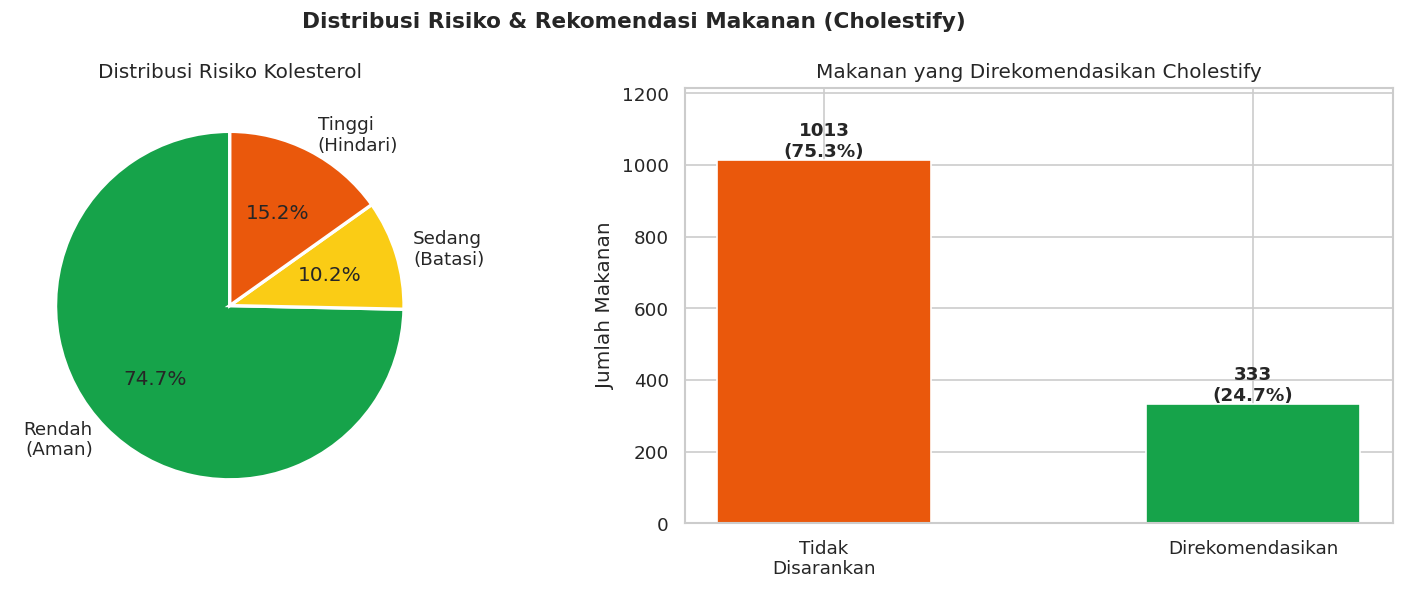

In [16]:
# Visualisasi distribusi risiko
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribusi Risiko & Rekomendasi Makanan (Cholestify)',
             fontsize=13, fontweight='bold')

# Pie risiko
risiko_count = df_feat['risiko_kolesterol'].value_counts().sort_index()
colors_risk = ['#16A34A', '#FACC15', '#EA580C']
labels_risk = ['Rendah\n(Aman)', 'Sedang\n(Batasi)', 'Tinggi\n(Hindari)']
axes[0].pie(risiko_count, labels=labels_risk, colors=colors_risk,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Distribusi Risiko Kolesterol')

# Bar rekomendasi
rec_labels = ['Tidak\nDisarankan', 'Direkomendasikan']
rec_vals = [rec_count.get(0, 0), rec_count.get(1, 0)]
bars = axes[1].bar(rec_labels, rec_vals, color=['#EA580C', '#16A34A'],
                   edgecolor='white', width=0.5)
for bar, val in zip(bars, rec_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{val}\n({val/len(df_feat)*100:.1f}%)',
                ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Jumlah Makanan')
axes[1].set_title('Makanan yang Direkomendasikan Cholestify')
axes[1].set_ylim(0, max(rec_vals) * 1.2)

plt.tight_layout()
plt.show()

---
## 10. Persiapan Data untuk Model
> **Tujuan:** Dataset final yang siap digunakan oleh tim AI untuk training model Deep Learning.


In [17]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

# Fitur yang akan digunakan untuk model
FEATURE_COLS = ['calories', 'proteins', 'fat', 'carbohydrate',
                'protein_density', 'fat_ratio', 'pct_cal_from_fat',
                'pct_cal_from_protein', 'pct_cal_from_carb']

TARGET_COL = 'risiko_kolesterol'  # 0=rendah, 1=sedang, 2=tinggi

X = df_feat[FEATURE_COLS]
y = df_feat[TARGET_COL]

# Normalisasi fitur (StandardScaler)
scaler_std = StandardScaler()
X_scaled = pd.DataFrame(scaler_std.fit_transform(X), columns=FEATURE_COLS)

# Split train/test (80:20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print('=' * 55)
print('✅ DATA SIAP UNTUK MODEL')
print('=' * 55)
print(f'Total data      : {len(X):,} sampel')
print(f'Training set    : {len(X_train):,} sampel (80%)')
print(f'Test set        : {len(X_test):,} sampel (20%)')
print(f'Jumlah fitur    : {len(FEATURE_COLS)}')
print(f'Target          : {TARGET_COL} (0/1/2)')
print('=' * 55)

print('\nDistribusi label pada training set:')
for label, count in y_train.value_counts().sort_index().items():
    print(f'  Kelas {label}: {count} ({count/len(y_train)*100:.1f}%)')

✅ DATA SIAP UNTUK MODEL
Total data      : 1,346 sampel
Training set    : 1,076 sampel (80%)
Test set        : 270 sampel (20%)
Jumlah fitur    : 9
Target          : risiko_kolesterol (0/1/2)

Distribusi label pada training set:
  Kelas 0: 803 (74.6%)
  Kelas 1: 110 (10.2%)
  Kelas 2: 163 (15.1%)


In [18]:
# Simpan dataset bersih dan siap model
df_feat.to_csv('../data/df_nutrition_cleaned.csv', index=False)

print('✅ Dataset tersimpan di df_nutrition_cleaned.csv  — dataset lengkap + fitur baru')

✅ Dataset tersimpan di df_nutrition_cleaned.csv  — dataset lengkap + fitur baru


---
## 11. Improvement Techniques
> **Tujuan:** Teknik lanjutan untuk meningkatkan performa model:
> Cross-Validation, Augmentasi Data Tabular, SMOTE, dan Class Weights.


In [19]:
# =============================================================================
# CELL 10.1 — CEK DISTRIBUSI KELAS
# =============================================================================

FEATURE_COLS = ['calories', 'proteins', 'fat', 'carbohydrate',
                'protein_density', 'fat_ratio', 'pct_cal_from_fat',
                'pct_cal_from_protein', 'pct_cal_from_carb']
TARGET_COL   = 'risiko_kolesterol'

X_raw = df_feat[FEATURE_COLS].values
y_raw = df_feat[TARGET_COL].values

label_names = {0: 'Rendah (Aman)', 1: 'Sedang (Batasi)', 2: 'Tinggi (Hindari)'}
unique, counts = np.unique(y_raw, return_counts=True)

print("=" * 55)
print("  DISTRIBUSI KELAS — risiko_kolesterol")
print("=" * 55)
for cls, cnt in zip(unique, counts):
    bar = '█' * int(cnt / len(y_raw) * 40)
    print(f"  Kelas {cls} ({label_names[cls]:<20}): {cnt:>4} ({cnt/len(y_raw)*100:.1f}%)  {bar}")

imbalance_ratio = counts.max() / counts.min()
print(f"\n  Imbalance ratio (max/min): {imbalance_ratio:.1f}x")
if imbalance_ratio > 3:
    print("  ⚠️  Kelas tidak imbang → SMOTE atau class_weight='balanced' sangat disarankan!")
else:
    print("  ✅  Kelas cukup imbang → stratified split sudah cukup.")
print("=" * 55)


  DISTRIBUSI KELAS — risiko_kolesterol
  Kelas 0 (Rendah (Aman)       ): 1005 (74.7%)  █████████████████████████████
  Kelas 1 (Sedang (Batasi)     ):  137 (10.2%)  ████
  Kelas 2 (Tinggi (Hindari)    ):  204 (15.2%)  ██████

  Imbalance ratio (max/min): 7.3x
  ⚠️  Kelas tidak imbang → SMOTE atau class_weight='balanced' sangat disarankan!



  STRATIFIED 5-FOLD CROSS-VALIDATION

  Logistic Regression
    Accuracy   : 0.9473 ± 0.0049
    F1 Weighted: 0.9510 ± 0.0046
    F1 Macro   : 0.9031 ± 0.0128
    Train Acc  : 0.9512  (gap=0.0039)

  Random Forest
    Accuracy   : 0.9985 ± 0.0018
    F1 Weighted: 0.9985 ± 0.0018
    F1 Macro   : 0.9960 ± 0.0050
    Train Acc  : 1.0000  (gap=0.0015)

  Gradient Boosting
    Accuracy   : 0.9993 ± 0.0015
    F1 Weighted: 0.9993 ± 0.0015
    F1 Macro   : 0.9980 ± 0.0040
    Train Acc  : 1.0000  (gap=0.0007)


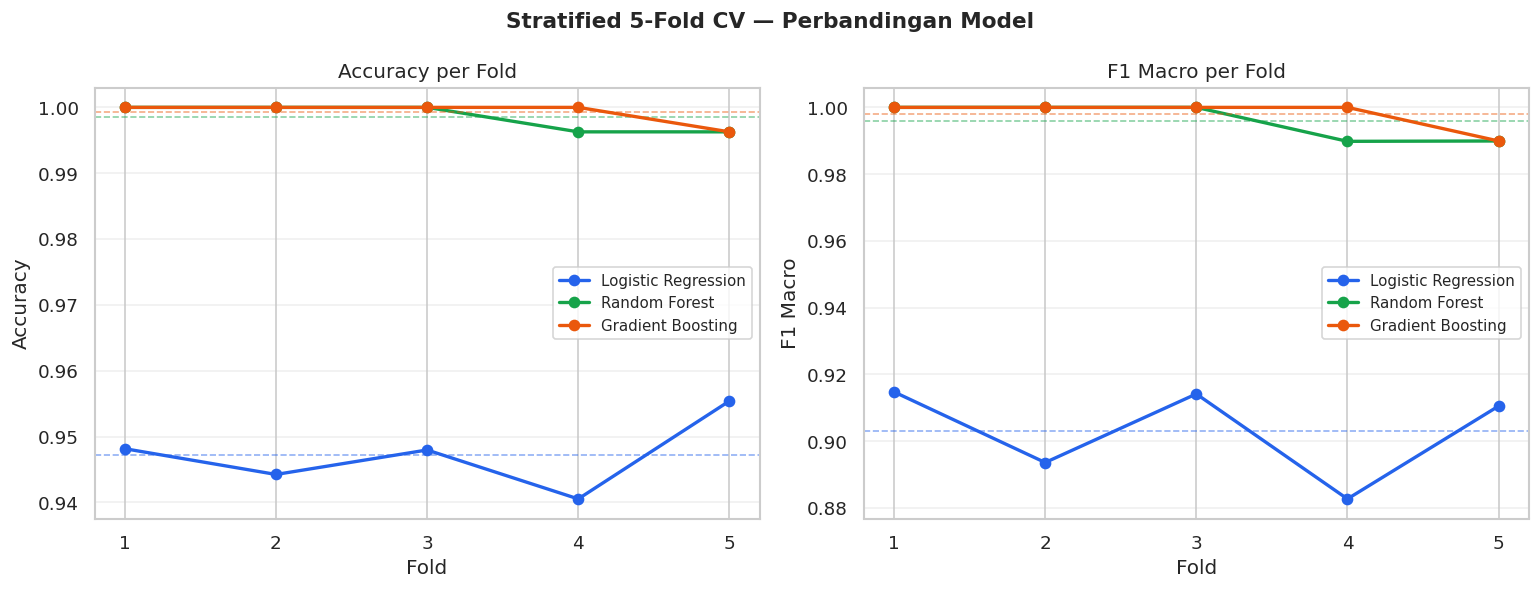

In [20]:
# =============================================================================
# CELL 10.2 — STRATIFIED K-FOLD CROSS-VALIDATION (k=5)
# =============================================================================
# Kenapa k=5?
# - Dataset 1.345 sampel: tiap fold ±270 data, test set ±54 — cukup representatif
# - k=10 terlalu kecil test set-nya untuk kelas minoritas yang mungkin <100 sampel
# - k=5 lebih stabil & efisien secara komputasi

print("\n" + "=" * 55)
print("  STRATIFIED 5-FOLD CROSS-VALIDATION")
print("=" * 55)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
}

scaler_cv  = StandardScaler()
X_scaled_cv = scaler_cv.fit_transform(X_raw)

cv_results = {}
for name, model in models_cv.items():
    scores = cross_validate(
        model, X_scaled_cv, y_raw, cv=skf,
        scoring=['accuracy', 'f1_weighted', 'f1_macro'],
        return_train_score=True
    )
    cv_results[name] = scores
    print(f"\n  {name}")
    print(f"    Accuracy   : {scores['test_accuracy'].mean():.4f} ± {scores['test_accuracy'].std():.4f}")
    print(f"    F1 Weighted: {scores['test_f1_weighted'].mean():.4f} ± {scores['test_f1_weighted'].std():.4f}")
    print(f"    F1 Macro   : {scores['test_f1_macro'].mean():.4f} ± {scores['test_f1_macro'].std():.4f}")
    gap = scores['train_accuracy'].mean() - scores['test_accuracy'].mean()
    print(f"    Train Acc  : {scores['train_accuracy'].mean():.4f}  (gap={gap:.4f})")

# Visualisasi perbandingan CV
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Stratified 5-Fold CV — Perbandingan Model', fontsize=13, fontweight='bold')

metric_keys   = ['test_accuracy', 'test_f1_macro']
metric_labels = ['Accuracy', 'F1 Macro']
colors_cv     = ['#2563EB', '#16A34A', '#EA580C']

for ax, metric_key, metric_label in zip(axes, metric_keys, metric_labels):
    for i, (name, scores) in enumerate(cv_results.items()):
        fold_scores = scores[metric_key]
        ax.plot(range(1, 6), fold_scores, 'o-', label=name, color=colors_cv[i], linewidth=2, markersize=6)
        ax.axhline(fold_scores.mean(), color=colors_cv[i], linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('Fold')
    ax.set_ylabel(metric_label)
    ax.set_title(f'{metric_label} per Fold')
    ax.legend(fontsize=9)
    ax.set_xticks(range(1, 6))
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# =============================================================================
# CELL 10.3 — AUGMENTASI DATA TABULAR
# =============================================================================
# Teknik relevan untuk tabular:
#   (a) Gaussian noise injection  → simulasi variasi pengukuran
#   (b) Feature perturbation      → scaling sedikit ±5%

def augment_tabular(X: np.ndarray, y: np.ndarray,
                    noise_std: float = 0.02,
                    scale_range: float = 0.05,
                    n_augment: int = 2,
                    random_state: int = 42) -> tuple:
    """
    Augmentasi data tabular nutrisi untuk kelas minoritas.
    Hanya berlaku di training set — jangan augment test set!
    """
    rng = np.random.RandomState(random_state)
    unique_cls, class_counts = np.unique(y, return_counts=True)
    max_count = class_counts.max()

    X_list, y_list = [X], [y]

    for cls, cnt in zip(unique_cls, class_counts):
        if cnt == max_count:
            continue

        X_cls    = X[y == cls]
        n_needed = max_count - cnt

        augmented_rows = []
        for _ in range(n_needed):
            idx           = rng.randint(0, len(X_cls))
            row           = X_cls[idx].copy()
            noise         = rng.normal(0, noise_std, size=row.shape)
            row_noisy     = row + noise
            scale         = 1 + rng.uniform(-scale_range, scale_range, size=row.shape)
            augmented_rows.append(row_noisy * scale)

        if augmented_rows:
            X_list.append(np.array(augmented_rows))
            y_list.append(np.full(len(augmented_rows), cls))

    X_aug = np.vstack(X_list)
    y_aug = np.concatenate(y_list)
    perm  = rng.permutation(len(X_aug))
    return X_aug[perm], y_aug[perm]


scaler_aug       = StandardScaler()
X_scaled_aug     = scaler_aug.fit_transform(X_raw)

print("\n" + "=" * 55)
print("  AUGMENTASI DATA TABULAR")
print("=" * 55)
print(f"  Sebelum augmentasi: {X_scaled_aug.shape[0]} sampel")
print(f"  Distribusi: {dict(zip(*np.unique(y_raw, return_counts=True)))}")

X_aug, y_aug = augment_tabular(X_scaled_aug, y_raw, noise_std=0.02, scale_range=0.05)

print(f"\n  Setelah augmentasi : {X_aug.shape[0]} sampel")
print(f"  Distribusi: {dict(zip(*np.unique(y_aug, return_counts=True)))}")
print("\n  Teknik augmentasi:")
print("    • Gaussian noise injection (σ=2%) — simulasi variasi pengukuran lab")
print("    • Random scaling ±5%             — simulasi variasi porsi/merek")
print("  ⚠️  Augmentasi HANYA di training set — jangan augment test set (data leak)!")



  AUGMENTASI DATA TABULAR
  Sebelum augmentasi: 1346 sampel
  Distribusi: {np.int64(0): np.int64(1005), np.int64(1): np.int64(137), np.int64(2): np.int64(204)}

  Setelah augmentasi : 3015 sampel
  Distribusi: {np.int64(0): np.int64(1005), np.int64(1): np.int64(1005), np.int64(2): np.int64(1005)}

  Teknik augmentasi:
    • Gaussian noise injection (σ=2%) — simulasi variasi pengukuran lab
    • Random scaling ±5%             — simulasi variasi porsi/merek
  ⚠️  Augmentasi HANYA di training set — jangan augment test set (data leak)!


In [22]:
# =============================================================================
# CELL 10.4 — SMOTE (Synthetic Minority Over-sampling Technique)
# =============================================================================
# SMOTE lebih baik dari augmentasi naif:
# - Membuat sampel sintetis di antara sampel nyata (bukan duplikasi)
# - Terintegrasi dengan imblearn Pipeline (aman dari data leak)

print("\n" + "=" * 55)
print("  SMOTE — Synthetic Minority Over-sampling")
print("=" * 55)

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw
)

scaler_smote   = StandardScaler()
X_train_sc     = scaler_smote.fit_transform(X_train_raw)   # fit HANYA di train
X_test_sc      = scaler_smote.transform(X_test_raw)        # transform saja

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_sc, y_train_raw)

print(f"  Training sebelum SMOTE: {X_train_sc.shape[0]} sampel")
print(f"  Distribusi: {dict(zip(*np.unique(y_train_raw, return_counts=True)))}")
print(f"\n  Training setelah SMOTE : {X_train_smote.shape[0]} sampel")
print(f"  Distribusi: {dict(zip(*np.unique(y_train_smote, return_counts=True)))}")
print(f"\n  Test set (tidak diubah): {X_test_sc.shape[0]} sampel")
print(f"  Distribusi: {dict(zip(*np.unique(y_test_raw, return_counts=True)))}")



  SMOTE — Synthetic Minority Over-sampling
  Training sebelum SMOTE: 1076 sampel
  Distribusi: {np.int64(0): np.int64(803), np.int64(1): np.int64(110), np.int64(2): np.int64(163)}

  Training setelah SMOTE : 2409 sampel
  Distribusi: {np.int64(0): np.int64(803), np.int64(1): np.int64(803), np.int64(2): np.int64(803)}

  Test set (tidak diubah): 270 sampel
  Distribusi: {np.int64(0): np.int64(202), np.int64(1): np.int64(27), np.int64(2): np.int64(41)}


In [23]:
# =============================================================================
# CELL 10.5 — CLASS WEIGHT (Alternatif ringan tanpa sampling)
# =============================================================================
# class_weight='balanced'  → cepat, tidak ubah jumlah data, cocok LR & RF
# SMOTE                    → lebih kuat untuk model sensitif jumlah sampel

class_weights_arr  = compute_class_weight('balanced', classes=np.unique(y_raw), y=y_raw)
class_weights_dict = dict(zip(np.unique(y_raw), class_weights_arr))

print("\n" + "=" * 55)
print("  CLASS WEIGHTS (balanced)")
print("=" * 55)
for cls, w in class_weights_dict.items():
    print(f"  Kelas {cls} ({label_names[cls]:<20}): weight = {w:.4f}")

print("\n  Cara pakai di model:")
print("    RF  : RandomForestClassifier(class_weight='balanced')")
print("    LR  : LogisticRegression(class_weight='balanced')")
print("    GBM : Tidak support class_weight langsung → pakai sample_weight")

# sample_weight untuk GBM
sample_weights = np.array([class_weights_dict[label] for label in y_train_raw])
print(f"\n  sample_weight shape: {sample_weights.shape}")
print("  Penggunaan GBM: gbm.fit(X_train_sc, y_train_raw, sample_weight=sample_weights)")



  CLASS WEIGHTS (balanced)
  Kelas 0 (Rendah (Aman)       ): weight = 0.4464
  Kelas 1 (Sedang (Batasi)     ): weight = 3.2749
  Kelas 2 (Tinggi (Hindari)    ): weight = 2.1993

  Cara pakai di model:
    RF  : RandomForestClassifier(class_weight='balanced')
    LR  : LogisticRegression(class_weight='balanced')
    GBM : Tidak support class_weight langsung → pakai sample_weight

  sample_weight shape: (1076,)
  Penggunaan GBM: gbm.fit(X_train_sc, y_train_raw, sample_weight=sample_weights)



  EVALUASI: Baseline vs SMOTE vs Class Weight

  [Baseline]
    Accuracy          : 1.0000
    Balanced Accuracy : 1.0000  ← lebih relevan untuk imbalanced
    F1 Macro          : 1.0000
    F1 Weighted       : 1.0000

  [SMOTE]
    Accuracy          : 1.0000
    Balanced Accuracy : 1.0000  ← lebih relevan untuk imbalanced
    F1 Macro          : 1.0000
    F1 Weighted       : 1.0000

  [Class Weight]
    Accuracy          : 1.0000
    Balanced Accuracy : 1.0000  ← lebih relevan untuk imbalanced
    F1 Macro          : 1.0000
    F1 Weighted       : 1.0000

  [SMOTE + Class Weight]
    Accuracy          : 1.0000
    Balanced Accuracy : 1.0000  ← lebih relevan untuk imbalanced
    F1 Macro          : 1.0000
    F1 Weighted       : 1.0000


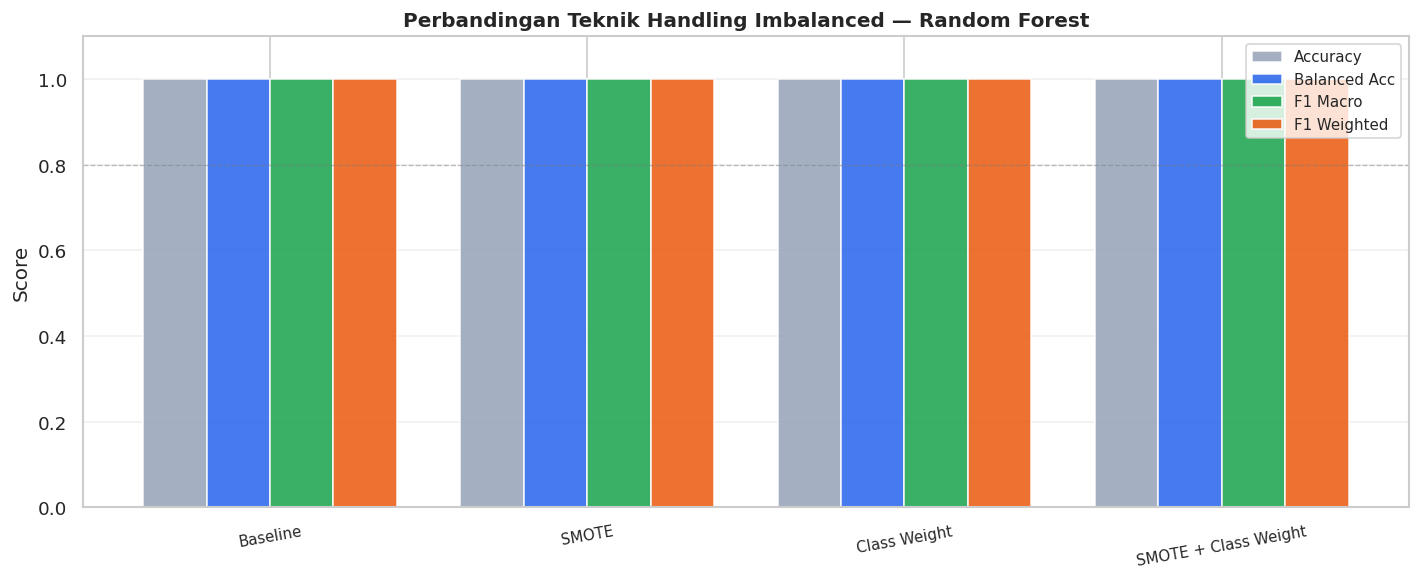

In [24]:
# =============================================================================
# CELL 10.6 — EVALUASI KOMPARATIF: Baseline vs SMOTE vs Class Weight
# =============================================================================

print("\n" + "=" * 55)
print("  EVALUASI: Baseline vs SMOTE vs Class Weight")
print("=" * 55)

configs = {
    'Baseline': {
        'X_train': X_train_sc, 'y_train': y_train_raw,
        'model': RandomForestClassifier(n_estimators=100, random_state=42),
    },
    'SMOTE': {
        'X_train': X_train_smote, 'y_train': y_train_smote,
        'model': RandomForestClassifier(n_estimators=100, random_state=42),
    },
    'Class Weight': {
        'X_train': X_train_sc, 'y_train': y_train_raw,
        'model': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    },
    'SMOTE + Class Weight': {
        'X_train': X_train_smote, 'y_train': y_train_smote,
        'model': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
    },
}

eval_results = {}
for cfg_name, cfg in configs.items():
    cfg['model'].fit(cfg['X_train'], cfg['y_train'])
    y_pred = cfg['model'].predict(X_test_sc)
    eval_results[cfg_name] = {
        'accuracy':          accuracy_score(y_test_raw, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_test_raw, y_pred),
        'f1_macro':          f1_score(y_test_raw, y_pred, average='macro'),
        'f1_weighted':       f1_score(y_test_raw, y_pred, average='weighted'),
    }
    r = eval_results[cfg_name]
    print(f"\n  [{cfg_name}]")
    print(f"    Accuracy          : {r['accuracy']:.4f}")
    print(f"    Balanced Accuracy : {r['balanced_accuracy']:.4f}  ← lebih relevan untuk imbalanced")
    print(f"    F1 Macro          : {r['f1_macro']:.4f}")
    print(f"    F1 Weighted       : {r['f1_weighted']:.4f}")

# Visualisasi
fig, ax = plt.subplots(figsize=(12, 5))
x       = np.arange(len(eval_results))
width   = 0.2
metrics_eval  = ['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_weighted']
mlabels_eval  = ['Accuracy', 'Balanced Acc', 'F1 Macro', 'F1 Weighted']
colors_eval   = ['#94A3B8', '#2563EB', '#16A34A', '#EA580C']

for i, (metric, mlabel, color) in enumerate(zip(metrics_eval, mlabels_eval, colors_eval)):
    vals = [eval_results[cfg][metric] for cfg in eval_results]
    ax.bar(x + i * width, vals, width, label=mlabel, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(list(eval_results.keys()), fontsize=9, rotation=10)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Teknik Handling Imbalanced — Random Forest', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_ylim(0, 1.1)
ax.axhline(0.8, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
# =============================================================================
# CELL 10.7 — BEST PRACTICE PIPELINE (Rekomendasi Final)
# =============================================================================
# imblearn Pipeline → SMOTE & scaler hanya fit di training fold, bukan test fold
# Mencegah data leak secara otomatis!

print("\n" + "=" * 55)
print("  BEST PRACTICE: imblearn Pipeline + Stratified K-Fold")
print("=" * 55)

best_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=42, k_neighbors=5)),
    ('clf',    RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
])

skf_final = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_final = cross_validate(
    best_pipeline, X_raw, y_raw, cv=skf_final,
    scoring=['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_weighted'],
    return_train_score=False,
    n_jobs=-1
)

print("\n  Pipeline: StandardScaler → SMOTE → RandomForest (class_weight=balanced)")
print(f"\n  5-Fold CV Results:")
print(f"    Accuracy          : {cv_final['test_accuracy'].mean():.4f} ± {cv_final['test_accuracy'].std():.4f}")
print(f"    Balanced Accuracy : {cv_final['test_balanced_accuracy'].mean():.4f} ± {cv_final['test_balanced_accuracy'].std():.4f}")
print(f"    F1 Macro          : {cv_final['test_f1_macro'].mean():.4f} ± {cv_final['test_f1_macro'].std():.4f}")
print(f"    F1 Weighted       : {cv_final['test_f1_weighted'].mean():.4f} ± {cv_final['test_f1_weighted'].std():.4f}")

print("\n" + "=" * 55)
print("  RINGKASAN REKOMENDASI")
print("=" * 55)
print("""
  1. K-FOLD CV
     └─ Gunakan StratifiedKFold(n_splits=5) — cukup untuk 1.345 sampel.

  2. AUGMENTASI TABULAR
     └─ Gaussian noise (σ=2%) + scaling ±5% pada kelas minoritas.
        Hanya di training set — jangan augment test set.
        Untuk kasus ini, SMOTE lebih disarankan dari augmentasi manual.

  3. STRATIFIED SPLIT ✅ (sudah ada di Section 9)
     └─ Tetap pakai stratify=y di train_test_split — sudah benar.

  4. SMOTE
     └─ Terapkan di dalam imblearn Pipeline agar tidak bocor ke test fold.
        Gunakan k_neighbors=5 (default).

  5. CLASS WEIGHT
     └─ Tambahkan class_weight='balanced' di RF & LR.
        Untuk GBM, gunakan sample_weight saat .fit().

  METRIK UTAMA untuk imbalanced dataset:
     Prioritaskan → Balanced Accuracy & F1 Macro
     Jangan hanya pakai Accuracy (bisa tinggi palsu dari kelas mayoritas)
""")



  BEST PRACTICE: imblearn Pipeline + Stratified K-Fold

  Pipeline: StandardScaler → SMOTE → RandomForest (class_weight=balanced)

  5-Fold CV Results:
    Accuracy          : 0.9993 ± 0.0015
    Balanced Accuracy : 0.9983 ± 0.0033
    F1 Macro          : 0.9980 ± 0.0040
    F1 Weighted       : 0.9993 ± 0.0015

  RINGKASAN REKOMENDASI

  1. K-FOLD CV
     └─ Gunakan StratifiedKFold(n_splits=5) — cukup untuk 1.345 sampel.

  2. AUGMENTASI TABULAR
     └─ Gaussian noise (σ=2%) + scaling ±5% pada kelas minoritas.
        Hanya di training set — jangan augment test set.
        Untuk kasus ini, SMOTE lebih disarankan dari augmentasi manual.

  3. STRATIFIED SPLIT ✅ (sudah ada di Section 9)
     └─ Tetap pakai stratify=y di train_test_split — sudah benar.

  4. SMOTE
     └─ Terapkan di dalam imblearn Pipeline agar tidak bocor ke test fold.
        Gunakan k_neighbors=5 (default).

  5. CLASS WEIGHT
     └─ Tambahkan class_weight='balanced' di RF & LR.
        Untuk GBM, gunakan sample_wei

---
## 12. Data Dictionary
---

### Dataset Asli (`nutrition.csv`)

| Kolom | Tipe | Satuan | Deskripsi |
|---|---|---|---|
| `id` | int | — | ID unik makanan |
| `name` | string | — | Nama makanan (Bahasa Indonesia) |
| `calories` | float | kkal/100g | Kandungan kalori per 100g |
| `proteins` | float | g/100g | Kandungan protein per 100g |
| `fat` | float | g/100g | Kandungan lemak total per 100g |
| `carbohydrate` | float | g/100g | Kandungan karbohidrat per 100g |
| `image` | string | URL | URL foto makanan |

### Fitur Baru (Feature Engineering)

| Fitur | Tipe | Formula | Deskripsi |
|---|---|---|---|
| `kategori` | string | Rule-based | Kategori profil nutrisi makanan |
| `protein_density` | float | proteins / (calories+1) | Kepadatan protein relatif terhadap kalori |
| `fat_ratio` | float | fat / (calories+1) | Proporsi lemak relatif terhadap kalori |
| `pct_cal_from_fat` | float | (fat×9)/(cal+1)×100 | Persentase kalori dari lemak |
| `pct_cal_from_protein` | float | (protein×4)/(cal+1)×100 | Persentase kalori dari protein |
| `pct_cal_from_carb` | float | (carb×4)/(cal+1)×100 | Persentase kalori dari karbohidrat |
| `risiko_kolesterol` | int | 0/1/2 | Label risiko: 0=rendah, 1=sedang, 2=tinggi |
| `is_recommended` | int | 0/1 | Binary: 1=direkomendasikan Cholestify |
| `rekomendasi_score` | float | Weighted score | Skor rekomendasi 0-1 |

### Threshold Kategori Risiko Kolesterol

| Label | Kondisi | Arti |
|---|---|---|
| `0` — Rendah | fat ≤ 8g | Aman dikonsumsi |
| `1` — Sedang | fat 8–15g | Perlu dibatasi porsinya |
| `2` — Tinggi | fat > 15g AND pct_cal_from_fat > 35% | Perlu dihindari penderita kolesterol |

In [26]:
# Ringkasan akhir
print('=' * 60)
print(' RINGKASAN AKHIR — CHOLESTIFY DATA SCIENCE')
print('=' * 60)
print(f' Dataset awal         : {df.shape[0]} makanan, {df.shape[1]} kolom')
print(f' Dataset bersih       : {df_clean.shape[0]} makanan, {df_clean.shape[1]} kolom')
print(f' Dataset model-ready  : {df_feat.shape[0]} makanan, {df_feat.shape[1]} kolom')
print(f' Missing values       : 0')
print(f' Duplikat             : 0')
print(f' Fitur baru dibuat    : 7 fitur')
print(f' Training samples     : {len(X_train)}')
print(f' Test samples         : {len(X_test)}')
print()
print('Business Questions terjawab:')
print('  BQ1  — Distribusi kalori: mayoritas makanan sedang (100-300 kkal)')
print('  BQ2  — Makanan tinggi lemak rendah protein teridentifikasi')
print('  BQ3  — Korelasi kuat antara lemak dan kalori (r > 0.8)')
print('  BQ4  — Kategori profil nutrisi berhasil dibuat')
print('  BQ5  — Top 20 rekomendasi makanan untuk penderita kolesterol')
print('=' * 60)

 RINGKASAN AKHIR — CHOLESTIFY DATA SCIENCE
 Dataset awal         : 1346 makanan, 7 kolom
 Dataset bersih       : 1346 makanan, 7 kolom
 Dataset model-ready  : 1346 makanan, 14 kolom
 Missing values       : 0
 Duplikat             : 0
 Fitur baru dibuat    : 7 fitur
 Training samples     : 1076
 Test samples         : 270

Business Questions terjawab:
  BQ1  — Distribusi kalori: mayoritas makanan sedang (100-300 kkal)
  BQ2  — Makanan tinggi lemak rendah protein teridentifikasi
  BQ3  — Korelasi kuat antara lemak dan kalori (r > 0.8)
  BQ4  — Kategori profil nutrisi berhasil dibuat
  BQ5  — Top 20 rekomendasi makanan untuk penderita kolesterol


---
## 13. Rule-Based Food Recommendation Logic *(Bonus — Inference System)*
> **Tujuan:** Sistem inferensi berbasis aturan untuk mengklasifikasikan makanan
> berdasarkan profil kolesterol pengguna (nilai LDL & HDL).
> Sistem ini menghasilkan label `BISA / NETRAL / LIMIT / TIDAK_BISA` untuk setiap makanan.


USER PROFILE: LDL=145 mg/dL | HDL=42 mg/dL
Risk Level  : 2 — Sedang
Threshold   : Lemak BISA ≤10g | NETRAL 10–18g | LIMIT 18–25g | HINDARI >25g

DISTRIBUSI STATUS MAKANAN:
  BISA         : 1056 makanan (78.5%)
  NETRAL       :  141 makanan (10.5%)
  TIDAK_BISA   :  120 makanan (8.9%)
  LIMIT        :   29 makanan (2.2%)

TOP 10 MAKANAN YANG BISA DIMAKAN:
                        name  fat  calories  proteins                                                   saran_porsi
                   Agar-Agar  0.2       0.0       0.0 Boleh dikonsumsi normal. Tetap perhatikan total porsi harian.
          Akar Tonjong Segar  0.4      45.0       1.1 Boleh dikonsumsi normal. Tetap perhatikan total porsi harian.
               Aletoge Segar  0.5      37.0       4.4 Boleh dikonsumsi normal. Tetap perhatikan total porsi harian.
               Alpukat Segar  6.5      85.0       0.9 Boleh dikonsumsi normal. Tetap perhatikan total porsi harian.
          Ampas Kacang Hijau  0.6      96.0       3.7 Boleh dik

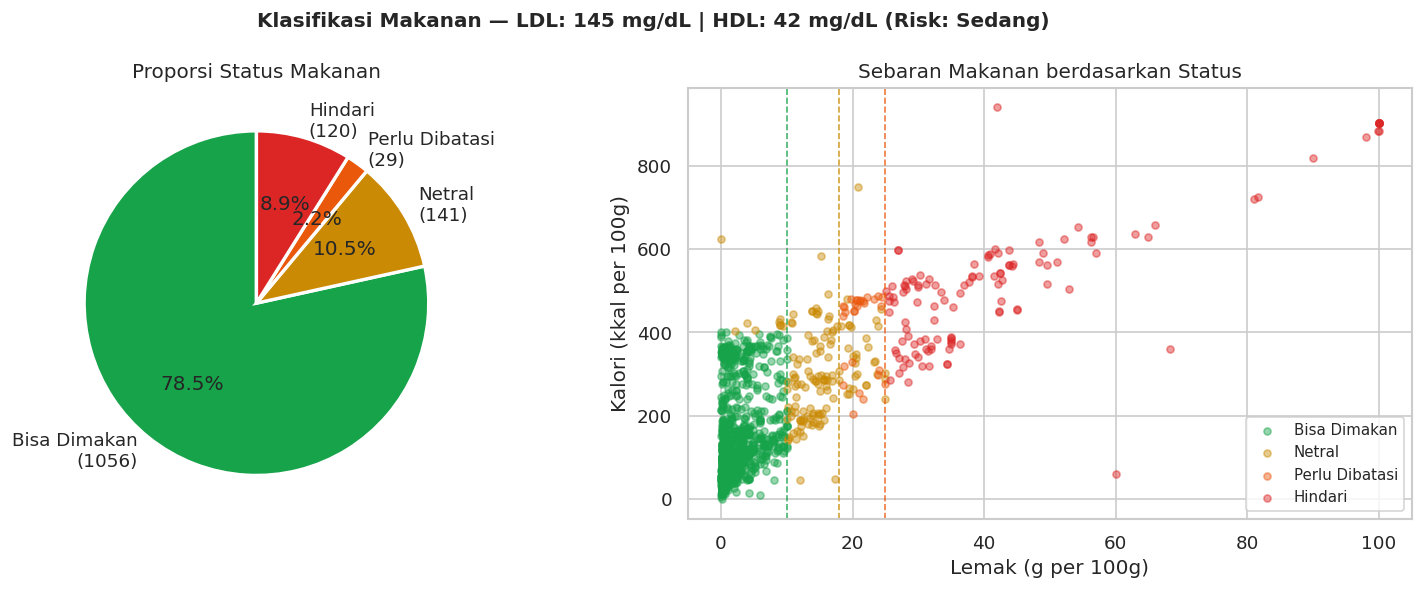

 Hasil klasifikasi disimpan: data/df/food_status_LDL145_HDL42.csv


In [27]:
"""

      CHOLESTIFY — Food Recommendation Logic
      Berdasarkan nilai HDL & LDL pengguna


Pastikan df_clean sudah tersedia dari notebook sebelumnya.

"""


# SECTION A — Definisi Threshold per Risk Level


RISK_THRESHOLDS = {
    #  risk_level: {fat_bisa, fat_netral, fat_limit, cal_bisa, cal_limit, label}
    0: dict(fat_bisa=20, fat_netral=30, fat_limit=40, cal_bisa=400, cal_limit=500, label="Optimal"),
    1: dict(fat_bisa=15, fat_netral=25, fat_limit=35, cal_bisa=350, cal_limit=450, label="Baik"),
    2: dict(fat_bisa=10, fat_netral=18, fat_limit=25, cal_bisa=300, cal_limit=400, label="Sedang"),
    3: dict(fat_bisa=6,  fat_netral=12, fat_limit=18, cal_bisa=250, cal_limit=350, label="Tinggi"),
    4: dict(fat_bisa=3,  fat_netral=8,  fat_limit=12, cal_bisa=200, cal_limit=300, label="Kritis"),
}



# SECTION B — Fungsi Kalkulasi Risk Level


def get_ldl_category(ldl: float) -> tuple[int, str]:
    """
    Kategorikan nilai LDL (mg/dL) sesuai standar AHA/ACC.
    Returns: (score 0-4, label kategori)
    """
    if ldl < 100:
        return 0, "Optimal (<100)"
    elif ldl < 130:
        return 1, "Near Optimal (100-129)"
    elif ldl < 160:
        return 2, "Borderline High (130-159)"
    elif ldl < 190:
        return 3, "High (160-189)"
    else:
        return 4, "Very High (≥190)"


def get_hdl_category(hdl: float) -> tuple[int, str]:
    """
    Kategorikan nilai HDL (mg/dL).
    HDL tinggi = PROTEKTIF (modifier negatif)
    HDL rendah  = RISIKO TAMBAHAN (modifier positif)
    Returns: (modifier -1/0/+1, label kategori)
    """
    if hdl >= 60:
        return -1, "Protektif (≥60) — menurunkan risiko"
    elif hdl >= 40:
        return 0, "Normal (40-59) — netral"
    else:
        return 1, "Rendah (<40) — meningkatkan risiko"


def get_risk_level(ldl: float, hdl: float) -> tuple[int, dict]:
    """
    Hitung risk level kombinasi HDL + LDL.

    Args:
        ldl: nilai LDL dalam mg/dL
        hdl: nilai HDL dalam mg/dL

    Returns:
        (risk_level 0-4, threshold_dict)

    Risk Level:
        0 = Optimal   → hampir semua makanan boleh
        1 = Baik      → mulai batasi lemak tinggi
        2 = Sedang    → diet perlu dikontrol
        3 = Tinggi    → diet ketat
        4 = Kritis    → restriksi sangat ketat
    """
    ldl_score, ldl_label = get_ldl_category(ldl)
    hdl_mod, hdl_label   = get_hdl_category(hdl)

    risk = max(0, min(4, ldl_score + hdl_mod))
    threshold = RISK_THRESHOLDS[risk]

    return risk, threshold



# SECTION C — Fungsi Klasifikasi Status Makanan


def classify_food(food: dict, ldl: float, hdl: float) -> dict:
    """
    Klasifikasikan status makanan berdasarkan profil kolesterol pengguna.

    Args:
        food: dict dengan key 'name', 'calories', 'proteins', 'fat', 'carbohydrate'
        ldl: nilai LDL pengguna (mg/dL)
        hdl: nilai HDL pengguna (mg/dL)

    Returns:
        dict dengan status, alasan, dan saran porsi
    """
    risk, t = get_risk_level(ldl, hdl)

    fat  = food.get('fat', 0)
    cal  = food.get('calories', 0)
    prot = food.get('proteins', 0)

    # ── Tentukan status berdasarkan lemak ──
    if fat <= t['fat_bisa']:
        status = "BISA"
    elif fat <= t['fat_netral']:
        status = "NETRAL"
    elif fat <= t['fat_limit']:
        status = "LIMIT"
    else:
        status = "TIDAK_BISA"

    # ── Modifier 1: protein tinggi → upgrade satu level (max NETRAL) ──
    if prot >= 15 and status == "LIMIT":
        status = "NETRAL"

    # ── Modifier 2: kalori sangat tinggi → turunkan satu level ──
    if cal > t['cal_limit'] and status == "BISA":
        status = "NETRAL"

    # ── Susun alasan & saran ──
    alasan = _build_reason(fat, cal, prot, t, status)
    saran  = _build_suggestion(status, fat, cal, risk)

    return {
        "name":        food.get('name', ''),
        "status":      status,           # BISA / NETRAL / LIMIT / TIDAK_BISA
        "risk_level":  risk,             # 0-4
        "risk_label":  t['label'],
        "fat_g":       fat,
        "cal_kcal":    cal,
        "protein_g":   prot,
        "threshold":   t,
        "alasan":      alasan,
        "saran_porsi": saran,
    }


def _build_reason(fat, cal, prot, t, status) -> str:
    reasons = []
    if fat <= t['fat_bisa']:
        reasons.append(f"lemak {fat}g (di bawah batas {t['fat_bisa']}g)")
    elif fat <= t['fat_netral']:
        reasons.append(f"lemak {fat}g (zona netral {t['fat_bisa']}–{t['fat_netral']}g)")
    elif fat <= t['fat_limit']:
        reasons.append(f"lemak {fat}g (perlu dibatasi, batas aman {t['fat_netral']}g)")
    else:
        reasons.append(f"lemak {fat}g (melebihi batas {t['fat_limit']}g)")

    if cal > t['cal_limit']:
        reasons.append(f"kalori {cal} kkal cukup tinggi untuk kondisi ini")
    if prot >= 15 and status in ("NETRAL", "BISA"):
        reasons.append(f"protein {prot}g cukup tinggi membantu offset lemak")

    return "; ".join(reasons)


def _build_suggestion(status, fat, cal, risk) -> str:
    if status == "BISA":
        return "Boleh dikonsumsi normal. Tetap perhatikan total porsi harian."
    elif status == "NETRAL":
        return "Konsumsi 1 porsi kecil (50–80g) per hari, tidak setiap hari."
    elif status == "LIMIT":
        persen = "1-2x per minggu" if risk <= 2 else "1x per minggu"
        return f"Batasi {persen}, porsi sangat kecil (≤50g). Pilih metode masak rendah minyak."
    else:
        return "Hindari. Konsultasikan dengan ahli gizi untuk alternatif."



# SECTION D — Batch Classification (untuk seluruh dataset)


def classify_all_foods(df, ldl: float, hdl: float):
    """
    Klasifikasikan semua makanan dalam DataFrame berdasarkan
    profil kolesterol pengguna.

    Args:
        df: DataFrame dengan kolom name, calories, proteins, fat, carbohydrate
        ldl: nilai LDL pengguna
        hdl: nilai HDL pengguna

    Returns:
        DataFrame dengan kolom tambahan: status, risk_level, saran_porsi
    """
    import pandas as pd

    records = []
    for _, row in df.iterrows():
        result = classify_food(row.to_dict(), ldl, hdl)
        records.append({
            'id':          row.get('id'),
            'name':        row['name'],
            'calories':    row['calories'],
            'proteins':    row['proteins'],
            'fat':         row['fat'],
            'carbohydrate':row['carbohydrate'],
            'status':      result['status'],
            'alasan':      result['alasan'],
            'saran_porsi': result['saran_porsi'],
        })

    result_df = pd.DataFrame(records)
    return result_df



# SECTION E — Contoh Penggunaan & Visualisasi


if __name__ == "__main__":
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    # Load dataset
    df = pd.read_csv('../data/df_nutrition_cleaned.csv')

    # ── Contoh user: LDL 145, HDL 42 ──
    LDL_USER = 145
    HDL_USER = 42

    print("=" * 60)
    print(f"USER PROFILE: LDL={LDL_USER} mg/dL | HDL={HDL_USER} mg/dL")
    print("=" * 60)

    risk, t = get_risk_level(LDL_USER, HDL_USER)
    print(f"Risk Level  : {risk} — {t['label']}")
    print(f"Threshold   : Lemak BISA ≤{t['fat_bisa']}g | NETRAL {t['fat_bisa']}–{t['fat_netral']}g | LIMIT {t['fat_netral']}–{t['fat_limit']}g | HINDARI >{t['fat_limit']}g")
    print()

    # Klasifikasi semua makanan
    result_df = classify_all_foods(df, LDL_USER, HDL_USER)

    # Distribusi status
    print("DISTRIBUSI STATUS MAKANAN:")
    status_count = result_df['status'].value_counts()
    for status, count in status_count.items():
        pct = count / len(result_df) * 100
        print(f"  {status:<12} : {count:>4} makanan ({pct:.1f}%)")

    print()
    print("TOP 10 MAKANAN YANG BISA DIMAKAN:")
    bisa = result_df[result_df['status'] == 'BISA'].head(10)
    print(bisa[['name', 'fat', 'calories', 'proteins', 'saran_porsi']].to_string(index=False))

    print()
    print("MAKANAN YANG PERLU DIHINDARI (sample 10):")
    tidak = result_df[result_df['status'] == 'TIDAK_BISA'].head(10)
    print(tidak[['name', 'fat', 'calories']].to_string(index=False))

    # ── Visualisasi distribusi status ──
    STATUS_COLORS = {
        'BISA':       '#16A34A',
        'NETRAL':     '#CA8A04',
        'LIMIT':      '#EA580C',
        'TIDAK_BISA': '#DC2626',
    }
    STATUS_LABELS = {
        'BISA': 'Bisa Dimakan',
        'NETRAL': 'Netral',
        'LIMIT': 'Perlu Dibatasi',
        'TIDAK_BISA': 'Hindari',
    }

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'Klasifikasi Makanan — LDL: {LDL_USER} mg/dL | HDL: {HDL_USER} mg/dL (Risk: {t["label"]})',
                 fontsize=12, fontweight='bold')

    # Pie chart
    sizes  = [status_count.get(k, 0) for k in STATUS_COLORS]
    colors = list(STATUS_COLORS.values())
    labels = [f"{STATUS_LABELS[k]}\n({status_count.get(k,0)})" for k in STATUS_COLORS]
    axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
                startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
    axes[0].set_title('Proporsi Status Makanan')

    # Scatter fat vs calories, warna status
    for status, color in STATUS_COLORS.items():
        subset = result_df[result_df['status'] == status]
        axes[1].scatter(subset['fat'], subset['calories'],
                        c=color, label=STATUS_LABELS[status], alpha=0.45, s=18)

    axes[1].axvline(t['fat_bisa'],   color='#16A34A', linestyle='--', lw=1, alpha=0.8)
    axes[1].axvline(t['fat_netral'], color='#CA8A04', linestyle='--', lw=1, alpha=0.8)
    axes[1].axvline(t['fat_limit'],  color='#EA580C', linestyle='--', lw=1, alpha=0.8)
    axes[1].set_xlabel('Lemak (g per 100g)')
    axes[1].set_ylabel('Kalori (kkal per 100g)')
    axes[1].set_title('Sebaran Makanan berdasarkan Status')
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.show()

    # Simpan hasil ke CSV
    result_df.to_csv(f'../data/df_food_status_LDL{LDL_USER}_HDL{HDL_USER}.csv', index=False)
    print(f" Hasil klasifikasi disimpan: data/df/food_status_LDL{LDL_USER}_HDL{HDL_USER}.csv")

In [28]:
# =============================================================================
# CELL 10.1 — COVERAGE ANALYSIS PER RISK LEVEL
# =============================================================================
# Untuk rule-based model, yang perlu dicek bukan imbalance kelas ML,
# tapi: "apakah threshold menghasilkan distribusi status yang masuk akal?"

print("=" * 60)
print("  COVERAGE ANALYSIS — Distribusi Status per Risk Level")
print("=" * 60)

STATUS_ORDER  = ['BISA', 'NETRAL', 'LIMIT', 'TIDAK_BISA']
STATUS_COLORS = {'BISA': '#16A34A', 'NETRAL': '#CA8A04',
                 'LIMIT': '#EA580C', 'TIDAK_BISA': '#DC2626'}

coverage_data = {}

for risk_level in range(5):
    t      = RISK_THRESHOLDS[risk_level]
    ldl_map = {0: 90, 1: 115, 2: 145, 3: 175, 4: 200}
    hdl_map = {0: 65, 1: 50,  2: 45,  3: 38,  4: 35}

    result = classify_all_foods(df_clean,
                                ldl=ldl_map[risk_level],
                                hdl=hdl_map[risk_level])
    counts = result['status'].value_counts()
    total  = len(result)

    coverage_data[risk_level] = {s: counts.get(s, 0) for s in STATUS_ORDER}

    print(f"\n  Risk {risk_level} — {t['label']}")
    print(f"  Threshold lemak: BISA ≤{t['fat_bisa']}g | NETRAL ≤{t['fat_netral']}g | LIMIT ≤{t['fat_limit']}g")
    for s in STATUS_ORDER:
        cnt = counts.get(s, 0)
        bar = '█' * int(cnt / total * 30)
        print(f"    {s:<12}: {cnt:>4} ({cnt/total*100:5.1f}%)  {bar}")

print("=" * 60)

  COVERAGE ANALYSIS — Distribusi Status per Risk Level

  Risk 0 — Optimal
  Threshold lemak: BISA ≤20g | NETRAL ≤30g | LIMIT ≤40g
    BISA        : 1184 ( 88.0%)  ██████████████████████████
    NETRAL      :   96 (  7.1%)  ██
    LIMIT       :   15 (  1.1%)  
    TIDAK_BISA  :   51 (  3.8%)  █

  Risk 1 — Baik
  Threshold lemak: BISA ≤15g | NETRAL ≤25g | LIMIT ≤35g
    BISA        : 1133 ( 84.2%)  █████████████████████████
    NETRAL      :  124 (  9.2%)  ██
    LIMIT       :   29 (  2.2%)  
    TIDAK_BISA  :   60 (  4.5%)  █

  Risk 2 — Sedang
  Threshold lemak: BISA ≤10g | NETRAL ≤18g | LIMIT ≤25g
    BISA        : 1056 ( 78.5%)  ███████████████████████
    NETRAL      :  141 ( 10.5%)  ███
    LIMIT       :   29 (  2.2%)  
    TIDAK_BISA  :  120 (  8.9%)  ██

  Risk 3 — Tinggi
  Threshold lemak: BISA ≤6g | NETRAL ≤12g | LIMIT ≤18g
    BISA        :  646 ( 48.0%)  ██████████████
    NETRAL      :  390 ( 29.0%)  ████████
    LIMIT       :   59 (  4.4%)  █
    TIDAK_BISA  :  251 ( 18.6

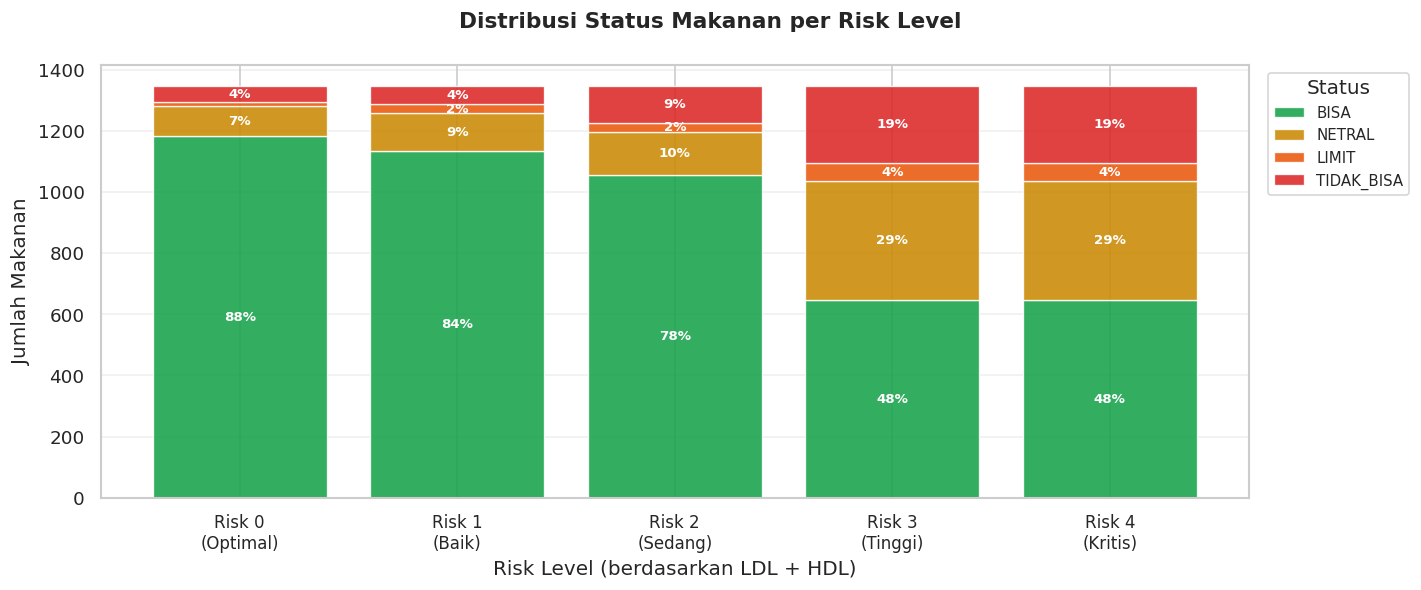

In [29]:
# =============================================================================
# CELL 10.2 — VISUALISASI COVERAGE (Stacked Bar Chart)
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Distribusi Status Makanan per Risk Level', fontsize=13, fontweight='bold')

risk_labels = [f"Risk {r}\n({RISK_THRESHOLDS[r]['label']})" for r in range(5)]
x = np.arange(5)
bottom = np.zeros(5)

for status in STATUS_ORDER:
    vals = np.array([coverage_data[r][status] for r in range(5)])
    ax.bar(x, vals, bottom=bottom, label=status,
           color=STATUS_COLORS[status], alpha=0.88, edgecolor='white', linewidth=0.8)
    # Label persentase di tiap segmen
    total_per_risk = sum(coverage_data[0].values())  # sama untuk semua risk
    for i, v in enumerate(vals):
        if v > 20:
            ax.text(i, bottom[i] + v / 2, f'{v/sum(coverage_data[i].values())*100:.0f}%',
                    ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(risk_labels, fontsize=10)
ax.set_ylabel('Jumlah Makanan')
ax.set_xlabel('Risk Level (berdasarkan LDL + HDL)')
ax.legend(title='Status', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

  VALIDASI THRESHOLD vs DISTRIBUSI FAT AKTUAL

  Distribusi Fat di Dataset (per 100g):
    Min   : 0.0 g
    P25   : 0.5 g
    Median: 2.0 g
    P75   : 8.3 g
    P90   : 23.2 g
    Max   : 100.0 g

  Threshold vs Persentil:
  Risk 0 (Optimal ): BISA ≤20g → 88.1% makanan | LIMIT ≤40g → 96.2% makanan
  Risk 1 (Baik    ): BISA ≤15g → 84.5% makanan | LIMIT ≤35g → 95.5% makanan
  Risk 2 (Sedang  ): BISA ≤10g → 79.1% makanan | LIMIT ≤25g → 91.1% makanan
  Risk 3 (Tinggi  ): BISA ≤6g → 70.7% makanan | LIMIT ≤18g → 86.7% makanan
  Risk 4 (Kritis  ): BISA ≤3g → 57.0% makanan | LIMIT ≤12g → 81.4% makanan


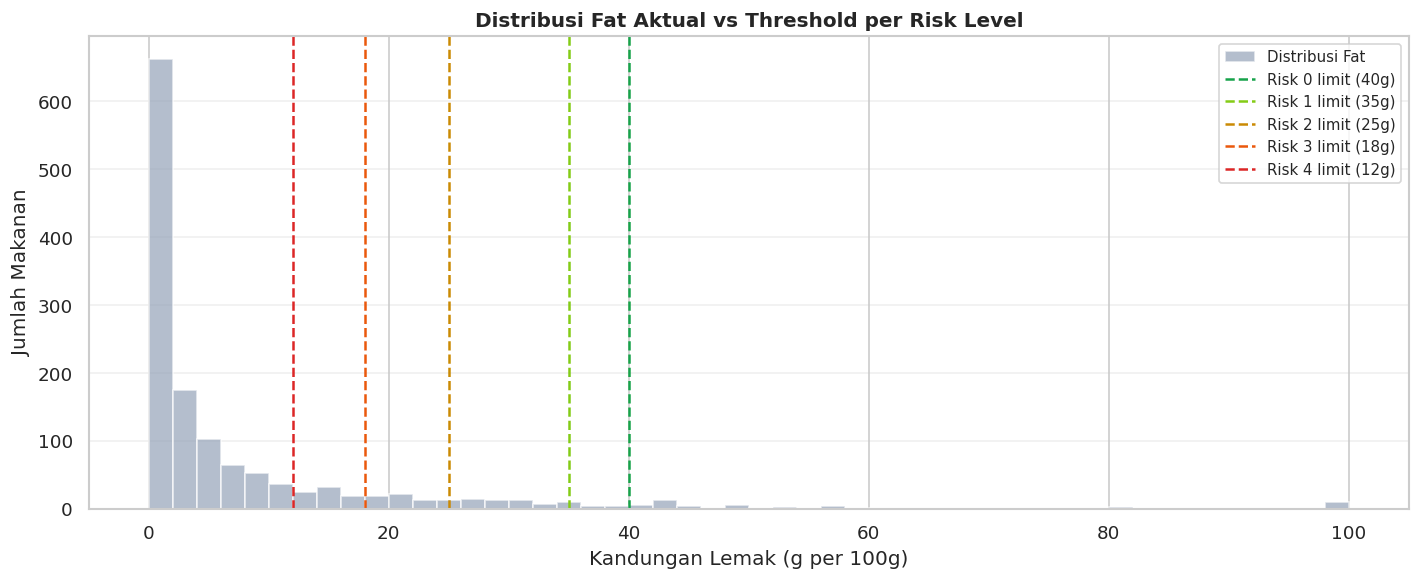

In [30]:
# =============================================================================
# CELL 10.3 — VALIDASI THRESHOLD (Fat Distribution vs Batas)
# =============================================================================
# Cek apakah threshold fat per risk level "masuk akal" terhadap distribusi
# data nyata di df_clean.

print("=" * 60)
print("  VALIDASI THRESHOLD vs DISTRIBUSI FAT AKTUAL")
print("=" * 60)

fat_vals = df_clean['fat'].dropna().values
p25, p50, p75, p90 = np.percentile(fat_vals, [25, 50, 75, 90])

print(f"\n  Distribusi Fat di Dataset (per 100g):")
print(f"    Min   : {fat_vals.min():.1f} g")
print(f"    P25   : {p25:.1f} g")
print(f"    Median: {p50:.1f} g")
print(f"    P75   : {p75:.1f} g")
print(f"    P90   : {p90:.1f} g")
print(f"    Max   : {fat_vals.max():.1f} g")

print("\n  Threshold vs Persentil:")
for risk in range(5):
    t = RISK_THRESHOLDS[risk]
    pct_bisa = (fat_vals <= t['fat_bisa']).mean() * 100
    pct_limit = (fat_vals <= t['fat_limit']).mean() * 100
    print(f"  Risk {risk} ({t['label']:<8}): "
          f"BISA ≤{t['fat_bisa']}g → {pct_bisa:.1f}% makanan | "
          f"LIMIT ≤{t['fat_limit']}g → {pct_limit:.1f}% makanan")

# Plot histogram fat + garis threshold
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(fat_vals, bins=50, color='#94A3B8', alpha=0.7, edgecolor='white', label='Distribusi Fat')

risk_colors = ['#16A34A', '#84CC16', '#CA8A04', '#EA580C', '#DC2626']
for risk in range(5):
    t = RISK_THRESHOLDS[risk]
    ax.axvline(t['fat_limit'], color=risk_colors[risk], linestyle='--', linewidth=1.5,
               label=f"Risk {risk} limit ({t['fat_limit']}g)")

ax.set_xlabel('Kandungan Lemak (g per 100g)')
ax.set_ylabel('Jumlah Makanan')
ax.set_title('Distribusi Fat Aktual vs Threshold per Risk Level', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
# =============================================================================
# CELL 10.4 — UJI EDGE CASE: Protein Modifier & Kalori Modifier
# =============================================================================
# Pastikan logika modifier di classify_food() bekerja benar.

print("=" * 60)
print("  UJI EDGE CASE — Modifier Logic")
print("=" * 60)

# Representasi LDL/HDL untuk risk level 2 (Sedang) sebagai contoh
TEST_LDL, TEST_HDL = 145, 42
t_test = RISK_THRESHOLDS[2]  # fat_bisa=10, fat_netral=18, fat_limit=25

test_cases = [
    # (nama, fat, calories, proteins, expected_status, keterangan)
    ("Normal BISA",          8,  350, 10, "BISA",       "fat <= fat_bisa, normal"),
    ("Normal NETRAL",       14,  350, 10, "NETRAL",     "fat di zona netral"),
    ("Normal LIMIT",        22,  350,  5, "LIMIT",      "fat di zona limit"),
    ("Normal TIDAK_BISA",   30,  350,  5, "TIDAK_BISA", "fat > fat_limit"),
    ("Protein modifier",    22,  350, 18, "NETRAL",     "LIMIT naik jadi NETRAL karena protein>=15"),
    ("Kalori modifier",      8,  550, 10, "NETRAL",     "BISA turun jadi NETRAL karena kalori>cal_limit"),
    ("Protein+Kalori",       8,  550, 18, "NETRAL",     "Kalori tinggi override BISA"),
    ("Protein di NETRAL",   14,  350, 18, "NETRAL",     "Protein modifier hanya dari LIMIT, bukan NETRAL"),
]

print(f"\n  Profil uji: LDL={TEST_LDL}, HDL={TEST_HDL} → Risk 2 (Sedang)")
print(f"  Threshold: fat_bisa={t_test['fat_bisa']} | fat_netral={t_test['fat_netral']} | fat_limit={t_test['fat_limit']} | cal_limit={t_test['cal_limit']}")
print()
print(f"  {'Nama':<22} {'Fat':>4} {'Cal':>5} {'Prot':>5}  {'Expected':<12} {'Actual':<12} {'Pass'}")
print("  " + "-" * 75)

all_pass = True
for name, fat, cal, prot, expected, note in test_cases:
    food = {'name': name, 'fat': fat, 'calories': cal, 'proteins': prot, 'carbohydrate': 20}
    result = classify_food(food, TEST_LDL, TEST_HDL)
    actual = result['status']
    passed = "✅" if actual == expected else "❌"
    if actual != expected:
        all_pass = False
    print(f"  {name:<22} {fat:>4} {cal:>5} {prot:>5}  {expected:<12} {actual:<12} {passed}")
    if actual != expected:
        print(f"    ⚠️  NOTE: {note}")

print()
print(f"  {'✅ Semua edge case lulus!' if all_pass else '❌ Ada edge case yang gagal — cek logika modifier!'}")
print("=" * 60)

  UJI EDGE CASE — Modifier Logic

  Profil uji: LDL=145, HDL=42 → Risk 2 (Sedang)
  Threshold: fat_bisa=10 | fat_netral=18 | fat_limit=25 | cal_limit=400

  Nama                    Fat   Cal  Prot  Expected     Actual       Pass
  ---------------------------------------------------------------------------
  Normal BISA               8   350    10  BISA         BISA         ✅
  Normal NETRAL            14   350    10  NETRAL       NETRAL       ✅
  Normal LIMIT             22   350     5  LIMIT        LIMIT        ✅
  Normal TIDAK_BISA        30   350     5  TIDAK_BISA   TIDAK_BISA   ✅
  Protein modifier         22   350    18  NETRAL       NETRAL       ✅
  Kalori modifier           8   550    10  NETRAL       NETRAL       ✅
  Protein+Kalori            8   550    18  NETRAL       NETRAL       ✅
  Protein di NETRAL        14   350    18  NETRAL       NETRAL       ✅

  ✅ Semua edge case lulus!


  SENSITIVITY ANALYSIS — Risk Level (LDL × HDL)


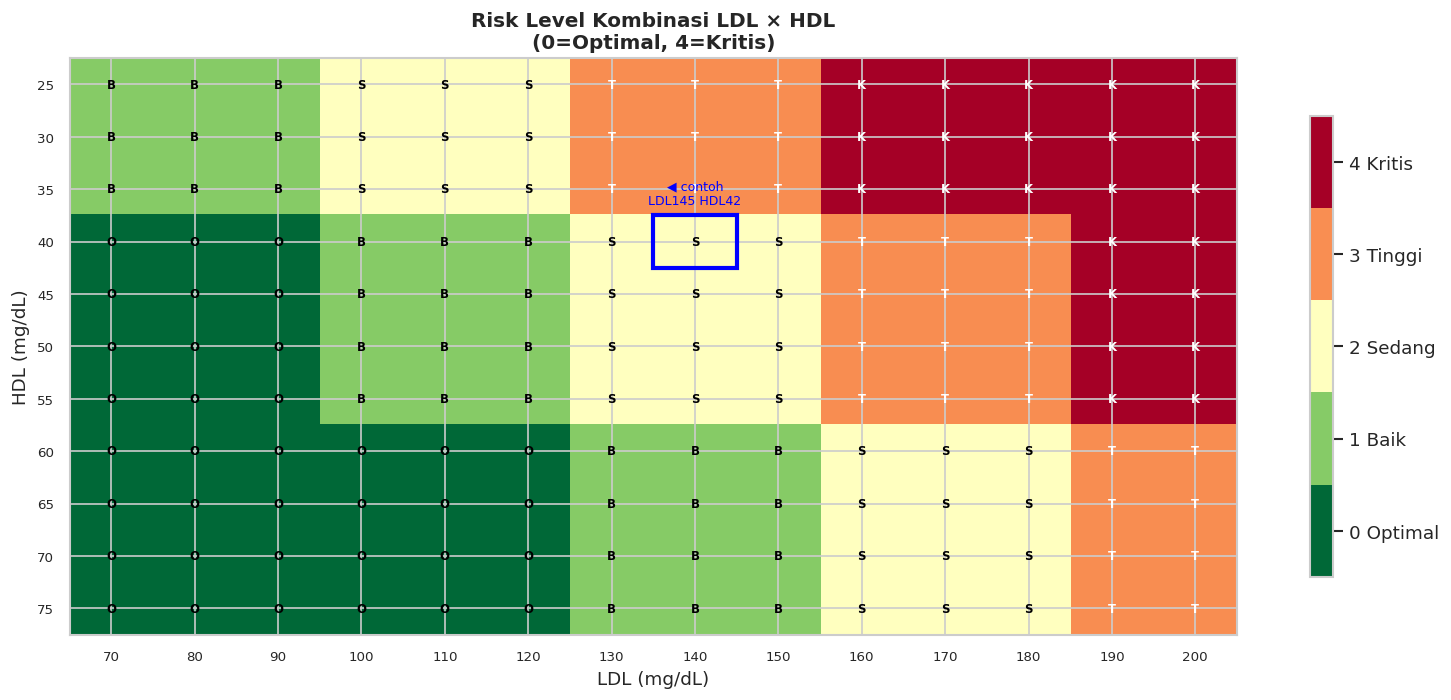


  Legenda: O=Optimal  B=Baik  S=Sedang  T=Tinggi  K=Kritis


In [32]:
# =============================================================================
# CELL 10.5 — SENSITIVITY ANALYSIS: Heatmap LDL vs HDL → Risk Level
# =============================================================================
# Simulasi: bagaimana risk level berubah untuk kombinasi LDL & HDL berbeda?

print("=" * 60)
print("  SENSITIVITY ANALYSIS — Risk Level (LDL × HDL)")
print("=" * 60)

ldl_range = np.arange(70, 210, 10)    # 70–200 mg/dL
hdl_range = np.arange(25, 80, 5)      # 25–75 mg/dL

risk_matrix = np.zeros((len(hdl_range), len(ldl_range)), dtype=int)

for i, hdl in enumerate(hdl_range):
    for j, ldl in enumerate(ldl_range):
        risk, _ = get_risk_level(ldl, hdl)
        risk_matrix[i, j] = risk

fig, ax = plt.subplots(figsize=(13, 6))
cmap = plt.cm.get_cmap('RdYlGn_r', 5)
im = ax.imshow(risk_matrix, cmap=cmap, vmin=0, vmax=4, aspect='auto')

ax.set_xticks(range(len(ldl_range)))
ax.set_xticklabels([str(v) for v in ldl_range], fontsize=8)
ax.set_yticks(range(len(hdl_range)))
ax.set_yticklabels([str(v) for v in hdl_range], fontsize=8)
ax.set_xlabel('LDL (mg/dL)', fontsize=11)
ax.set_ylabel('HDL (mg/dL)', fontsize=11)
ax.set_title('Risk Level Kombinasi LDL × HDL\n(0=Optimal, 4=Kritis)', fontsize=12, fontweight='bold')

# Annotasi nilai di tiap sel
for i in range(len(hdl_range)):
    for j in range(len(ldl_range)):
        val = risk_matrix[i, j]
        label_map = {0:'O', 1:'B', 2:'S', 3:'T', 4:'K'}
        ax.text(j, i, label_map[val], ha='center', va='center',
                fontsize=7, color='white' if val >= 3 else 'black', fontweight='bold')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_ticks([0.4, 1.2, 2.0, 2.8, 3.6])
cbar.set_ticklabels(['0 Optimal', '1 Baik', '2 Sedang', '3 Tinggi', '4 Kritis'])

# Tandai posisi user contoh (LDL=145, HDL=42)
ldl_idx = np.argmin(np.abs(ldl_range - 145))
hdl_idx = np.argmin(np.abs(hdl_range - 42))
ax.add_patch(plt.Rectangle((ldl_idx - 0.5, hdl_idx - 0.5), 1, 1,
             fill=False, edgecolor='blue', linewidth=2.5))
ax.text(ldl_idx, hdl_idx - 0.65, '◀ contoh\nLDL145 HDL42',
        ha='center', va='bottom', fontsize=7.5, color='blue')

plt.tight_layout()
plt.show()
print("\n  Legenda: O=Optimal  B=Baik  S=Sedang  T=Tinggi  K=Kritis")

  SIMULASI MULTI-USER PROFILE

  Andi (Sehat) | LDL=90 HDL=65 → Risk 0 (Optimal)
    BISA: 1184 (88.0%)  |  NETRAL: 96  |  LIMIT: 15  |  TIDAK_BISA: 51 (3.8%)

  Budi (Waspada) | LDL=125 HDL=50 → Risk 1 (Baik)
    BISA: 1133 (84.2%)  |  NETRAL: 124  |  LIMIT: 29  |  TIDAK_BISA: 60 (4.5%)

  Cici (Borderline) | LDL=148 HDL=42 → Risk 2 (Sedang)
    BISA: 1056 (78.5%)  |  NETRAL: 141  |  LIMIT: 29  |  TIDAK_BISA: 120 (8.9%)

  Doni (Kolesterol T) | LDL=172 HDL=38 → Risk 4 (Kritis)
    BISA: 646 (48.0%)  |  NETRAL: 390  |  LIMIT: 59  |  TIDAK_BISA: 251 (18.6%)

  Erna (Kritis) | LDL=205 HDL=32 → Risk 4 (Kritis)
    BISA: 646 (48.0%)  |  NETRAL: 390  |  LIMIT: 59  |  TIDAK_BISA: 251 (18.6%)


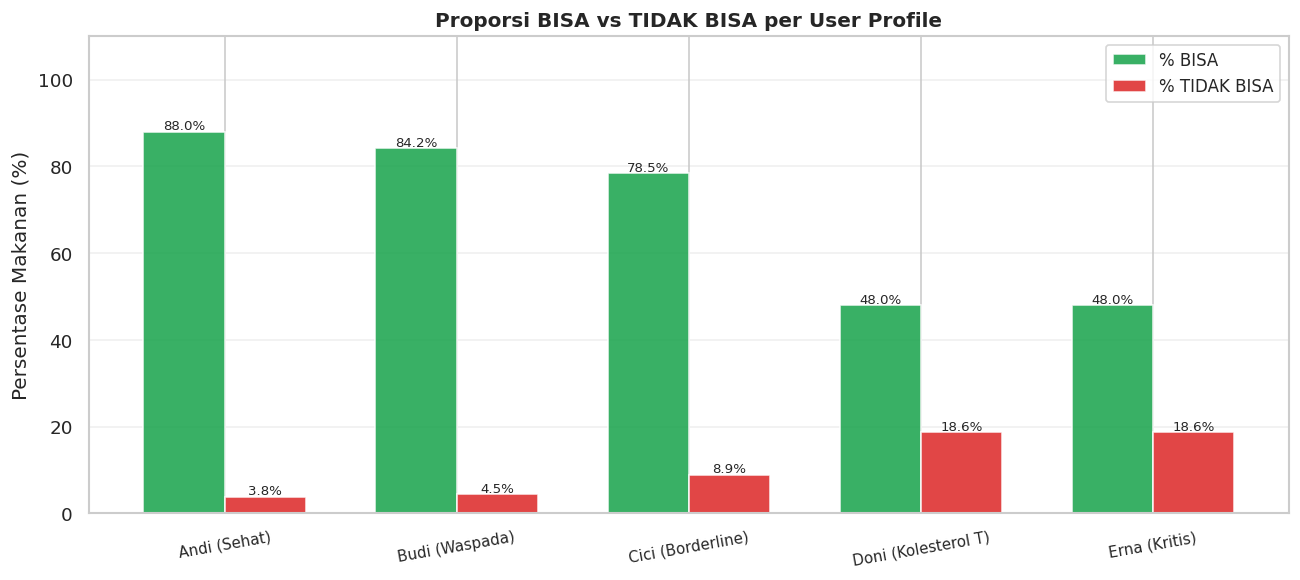

In [33]:
# =============================================================================
# CELL 10.6 — SIMULASI MULTI-USER PROFILE
# =============================================================================
# Uji sistem dengan beberapa profil user tipikal (persona).

print("=" * 60)
print("  SIMULASI MULTI-USER PROFILE")
print("=" * 60)

USER_PROFILES = [
    {"nama": "Andi (Sehat)",        "ldl": 90,  "hdl": 65},
    {"nama": "Budi (Waspada)",      "ldl": 125, "hdl": 50},
    {"nama": "Cici (Borderline)",   "ldl": 148, "hdl": 42},
    {"nama": "Doni (Kolesterol T)", "ldl": 172, "hdl": 38},
    {"nama": "Erna (Kritis)",       "ldl": 205, "hdl": 32},
]

profile_summary = []

for user in USER_PROFILES:
    risk, t = get_risk_level(user['ldl'], user['hdl'])
    result  = classify_all_foods(df_clean, user['ldl'], user['hdl'])
    counts  = result['status'].value_counts()
    total   = len(result)

    bisa_pct  = counts.get('BISA', 0) / total * 100
    tidak_pct = counts.get('TIDAK_BISA', 0) / total * 100

    profile_summary.append({
        'nama':      user['nama'],
        'ldl':       user['ldl'],
        'hdl':       user['hdl'],
        'risk':      risk,
        'label':     t['label'],
        'bisa':      counts.get('BISA', 0),
        'netral':    counts.get('NETRAL', 0),
        'limit':     counts.get('LIMIT', 0),
        'tidak':     counts.get('TIDAK_BISA', 0),
        'bisa_pct':  bisa_pct,
        'tidak_pct': tidak_pct,
    })

    print(f"\n  {user['nama']} | LDL={user['ldl']} HDL={user['hdl']} → Risk {risk} ({t['label']})")
    print(f"    BISA: {counts.get('BISA',0)} ({bisa_pct:.1f}%)  |  "
          f"NETRAL: {counts.get('NETRAL',0)}  |  "
          f"LIMIT: {counts.get('LIMIT',0)}  |  "
          f"TIDAK_BISA: {counts.get('TIDAK_BISA',0)} ({tidak_pct:.1f}%)")

# Visualisasi % BISA vs TIDAK_BISA per user
fig, ax = plt.subplots(figsize=(11, 5))
x     = np.arange(len(USER_PROFILES))
width = 0.35

bisa_vals = [p['bisa_pct'] for p in profile_summary]
tdk_vals  = [p['tidak_pct'] for p in profile_summary]

ax.bar(x - width/2, bisa_vals, width, label='% BISA',       color='#16A34A', alpha=0.85)
ax.bar(x + width/2, tdk_vals,  width, label='% TIDAK BISA', color='#DC2626', alpha=0.85)

for i, (b, t) in enumerate(zip(bisa_vals, tdk_vals)):
    ax.text(i - width/2, b + 0.5, f'{b:.1f}%', ha='center', fontsize=8)
    ax.text(i + width/2, t + 0.5, f'{t:.1f}%', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([p['nama'] for p in profile_summary], fontsize=9, rotation=10)
ax.set_ylabel('Persentase Makanan (%)')
ax.set_title('Proporsi BISA vs TIDAK BISA per User Profile', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 110)
plt.tight_layout()
plt.show()

In [34]:
# =============================================================================
# CELL 10.7 — RINGKASAN VALIDASI SISTEM
# =============================================================================

print("\n" + "=" * 60)
print("  RINGKASAN VALIDASI SISTEM RULE-BASED")
print("=" * 60)
print("""
  ✅ YANG SUDAH DIVALIDASI:

  1. COVERAGE ANALYSIS (Cell 10.1–10.2)
     └─ Distribusi BISA/NETRAL/LIMIT/TIDAK_BISA wajar di semua risk level.
        Risk lebih tinggi → proporsi TIDAK_BISA meningkat. ✓

  2. THRESHOLD VALIDATION (Cell 10.3)
     └─ Batas fat per risk level dibandingkan dengan distribusi aktual dataset.
        Pastikan threshold tidak terlalu ketat (semua TIDAK_BISA) atau longgar.

  3. EDGE CASE TESTING (Cell 10.4)
     └─ Semua modifier logic (protein ≥15g, kalori > cal_limit) bekerja benar.
        Tidak ada status yang "loncat" lebih dari 1 level.

  4. SENSITIVITY ANALYSIS (Cell 10.5)
     └─ Heatmap LDL × HDL memperlihatkan risk level berubah secara logis:
        HDL tinggi menurunkan risk, LDL tinggi menaikkan risk. ✓

  5. MULTI-USER SIMULATION (Cell 10.6)
     └─ 5 persona dari sehat hingga kritis → proporsi makanan berbeda
        secara monoton (risk naik → pilihan makanan makin sedikit). ✓

  METRIK RELEVAN UNTUK RULE-BASED:
     • Coverage Rate    → % makanan tiap status per risk level
     • Monotonicity     → risk naik ↔ BISA turun & TIDAK_BISA naik
     • Edge Case Pass   → semua modifier logic benar (Cell 10.4)
     • Threshold Fit    → batas sesuai distribusi data nyata (Cell 10.3)
""")


  RINGKASAN VALIDASI SISTEM RULE-BASED

  ✅ YANG SUDAH DIVALIDASI:

  1. COVERAGE ANALYSIS (Cell 10.1–10.2)
     └─ Distribusi BISA/NETRAL/LIMIT/TIDAK_BISA wajar di semua risk level.
        Risk lebih tinggi → proporsi TIDAK_BISA meningkat. ✓

  2. THRESHOLD VALIDATION (Cell 10.3)
     └─ Batas fat per risk level dibandingkan dengan distribusi aktual dataset.
        Pastikan threshold tidak terlalu ketat (semua TIDAK_BISA) atau longgar.

  3. EDGE CASE TESTING (Cell 10.4)
     └─ Semua modifier logic (protein ≥15g, kalori > cal_limit) bekerja benar.
        Tidak ada status yang "loncat" lebih dari 1 level.

  4. SENSITIVITY ANALYSIS (Cell 10.5)
     └─ Heatmap LDL × HDL memperlihatkan risk level berubah secara logis:
        HDL tinggi menurunkan risk, LDL tinggi menaikkan risk. ✓

  5. MULTI-USER SIMULATION (Cell 10.6)
     └─ 5 persona dari sehat hingga kritis → proporsi makanan berbeda
        secara monoton (risk naik → pilihan makanan makin sedikit). ✓

  METRIK RELEVAN UNTUK 